# NDT7 EDA — Vietnam Fixed/Broadband

Full exploratory analysis of Vietnam NDT7 (M-Lab) broadband data, mirroring the structure and
methodology of `notebooks/ookla/vietnam_eda.ipynb` (Part 1 — Fixed Broadband) so results are
directly comparable section-by-section with the Ookla Vietnam notebook and with Thailand's NDT7
notebook (`notebooks/ndt7/ndt7_edav2.ipynb`).

**Input:** `data/exports/ndt7_vietnam_province_quarterly.csv` — already aggregated to
province x quarter by `vietnam_ndt7_prep.ipynb` (tile-binned at Ookla's zoom-16 resolution,
`is_reliable` computed with the same `total_tests>=100 & n_tiles>=5` threshold, and merged
with `data/reference/vietnam_reference.csv`). This notebook does no raw-data processing —
it picks up where the prep notebook leaves off.

**Scope:** broadband only (no cellular/mobile NDT7 data exists for Vietnam — the prep
pipeline filtered to broadband-classified traffic only), covering 2023 Q1 – 2025 Q4 across
63 of Vietnam's 64 provinces (Côn Đảo, a small island district, has zero NDT7 test volume
in any quarter).

**Known caveat carried over from the prep notebook and the paper draft:** NDT7 reliable
coverage decays sharply over the study period — from ~48% of provinces reliable in 2023 Q1
to ~10% by 2025 Q4, with data volume concentrated early. Any later-period comparison in this
notebook should be read with that in mind.

## Province Reference Data

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/vietnam_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 64
Regions: ['Central Highlands', 'Mekong Delta', 'North Central Coast', 'Northeast', 'Northwest', 'Red River Delta', 'South Central Coast', 'Southeast']

    province_en              region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
       An Giang        Mekong Delta   2057000              540                338704.14              1
Bà Rịa–Vũng Tàu           Southeast   1303000              580               3286254.54              1
     Bình Dương           Southeast   2564000              901                327276.61              2
     Bình Phước           Southeast   1313000              145                322186.39              2
     Bình Thuận South Central Coast   1498000              155                276055.50              2
      Bình Định South Central Coast   1679000              245                275959.91              2
       Bạc Liêu        Mekong Delta   1105000              340                330710.59              2
   

### Population and GDP by Region — Summary

In [2]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


                     provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                            
Southeast                    7        20.04       1055.0            1219194.0            1219194.0
Mekong Delta                13        18.85        480.0             316292.0             316292.0
South Central Coast          8        10.67        282.0             299540.0             299540.0
Red River Delta             10        22.20       1271.0             266559.0             266559.0
Central Highlands            5         6.25        105.0             249900.0             249900.0
Northeast                    9         9.85        215.0             226035.0             226035.0
North Central Coast          6        11.43        204.0             221536.0             221536.0
Northwest                    6         5.42        104.0             169748.0             169748.0


### GDP per Capita vs Population Density — by Region

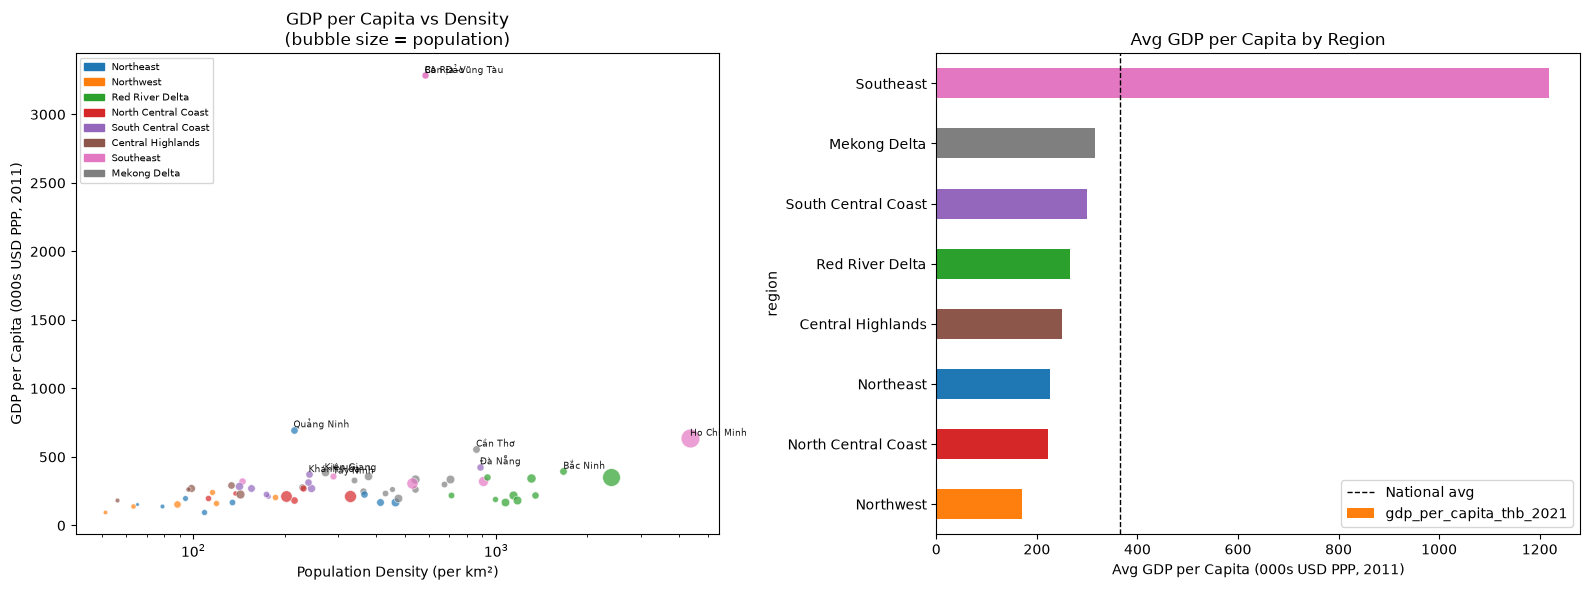

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Northeast': '#1f77b4',
    'Northwest': '#ff7f0e',
    'Red River Delta': '#2ca02c',
    'North Central Coast': '#d62728',
    'South Central Coast': '#9467bd',
    'Central Highlands': '#8c564b',
    'Southeast': '#e377c2',
    'Mekong Delta': '#7f7f7f',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD PPP, 2011)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD PPP, 2011)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

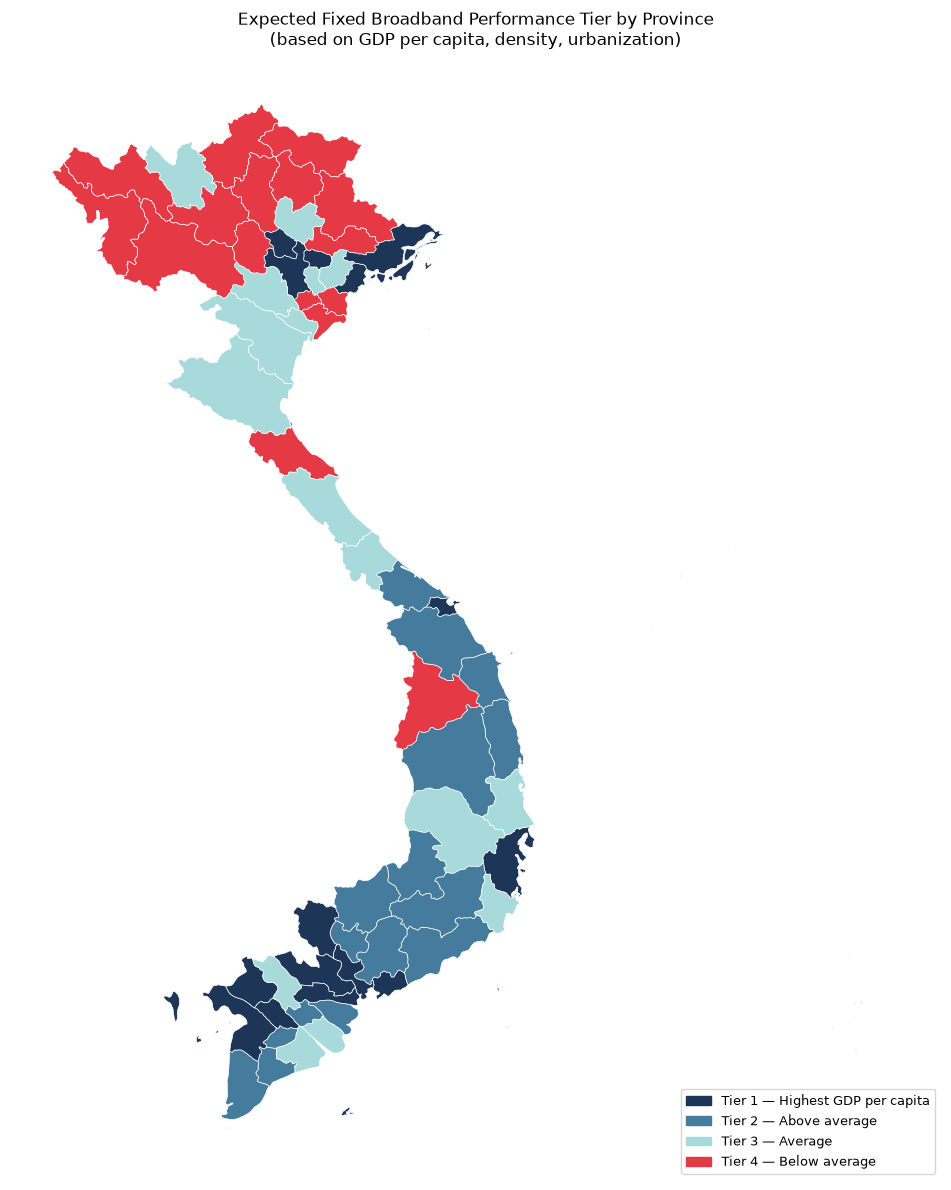

In [4]:
THAILAND_GEOJSON = '../../data/geo/vietnam_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {}  # no manual alignment needed: geojson 'name' already matches reference csv

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [5]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
    province_en              region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bà Rịa–Vũng Tàu           Southeast   1303000               3286254.54              1
        Côn Đảo           Southeast   1303000               3286254.54              1
     Quảng Ninh           Northeast   1387000                699887.25              1
    Ho Chi Minh           Southeast   9125000                638474.09              1
        Cần Thơ        Mekong Delta   1456000                559273.75              1
        Đà Nẵng South Central Coast   1294000                429834.96              1
       Bắc Ninh     Red River Delta   1447000                397659.74              1
     Kiên Giang        Mekong Delta   1789000                387388.18              1
      Khánh Hòa South Central Coast   1371000                373474.50              1
       Tây Ninh           Southeast   1207000                362573.14              1

=== BOTTOM 10 by GDP

---
## Full EDA — NDT7 Fixed Broadband, Vietnam (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

Data is already aggregated (prep notebook did the tile-binning, weighted averaging, and reliability flagging) — this just loads it and reconstructs the same field set (`period_start`, `month`, etc.) the Ookla notebooks build inline, so sections 2-25 below can reuse that logic unchanged.

In [6]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../data/exports/ndt7_vietnam_province_quarterly.csv'
GEOJSON  = '../../data/geo/vietnam_provinces.geojson'
PROV_REF = '../../data/reference/vietnam_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

# Re-load prov_ref fresh (shared-setup cell above may have mutated it) for the merges below
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")


Master shape: (733, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  63 (of 64 in reference — NDT7 has zero test volume for the rest)


In [7]:
# is_reliable already computed upstream (vietnam_ndt7_prep.ipynb, same total_tests>=100 & n_tiles>=5 threshold)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\nNote: reliable coverage decays sharply over the study period (concentrated NDT7 volume early) — "
      "see the paper draft's NDT7 cross-validation caveat.")


Reliable province-quarters per label:
label
2023-Q1    30
2023-Q2    29
2023-Q3    26
2023-Q4    20
2024-Q1    24
2024-Q2    16
2024-Q3    15
2024-Q4    15
2025-Q1    14
2025-Q2     8
2025-Q3     7
2025-Q4     6

Overall reliable: 210 / 733 (28.6%)

Note: reliable coverage decays sharply over the study period (concentrated NDT7 volume early) — see the paper draft's NDT7 cross-validation caveat.


### 2. Data Quality — Coverage per Province

In [8]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

# Low-test provinces (< 100 tests in any quarter present)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))


Expected rows (if every province had every quarter): 768 | Actual: 733 | Missing: 35

Provinces with ZERO NDT7 test volume in any quarter (1): ['Côn Đảo']

Low-test quarters (< 100 tests) — 48 of 733 province-quarter rows
      name   label  total_tests  n_tiles
   Bắc Kạn 2025-Q3          3.0      1.0
  Hưng Yên 2023-Q3          4.0      1.0
Ninh Thuận 2023-Q3          4.0      1.0
 Hậu Giang 2025-Q2          6.0      1.0
   Bắc Kạn 2024-Q4         13.0      1.0
   Bắc Kạn 2025-Q2         13.0      1.0
Ninh Thuận 2024-Q3         13.0      1.0
  Hưng Yên 2024-Q1         13.0      1.0
Bình Thuận 2024-Q4         14.0      1.0
Bình Thuận 2025-Q4         15.0      1.0
Ninh Thuận 2023-Q2         15.0      1.0
Bình Thuận 2024-Q3         15.0      2.0
   Bắc Kạn 2024-Q1         20.0      1.0
Quảng Ninh 2025-Q2         24.0      1.0
 Điện Biên 2023-Q4         28.0      1.0


In [9]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept, {master['name'].nunique()} provinces represented")


Filtered to reliable province-quarters: 210 rows kept, 42 provinces represented


### 3. Speed Distribution — All Provinces, All Quarters

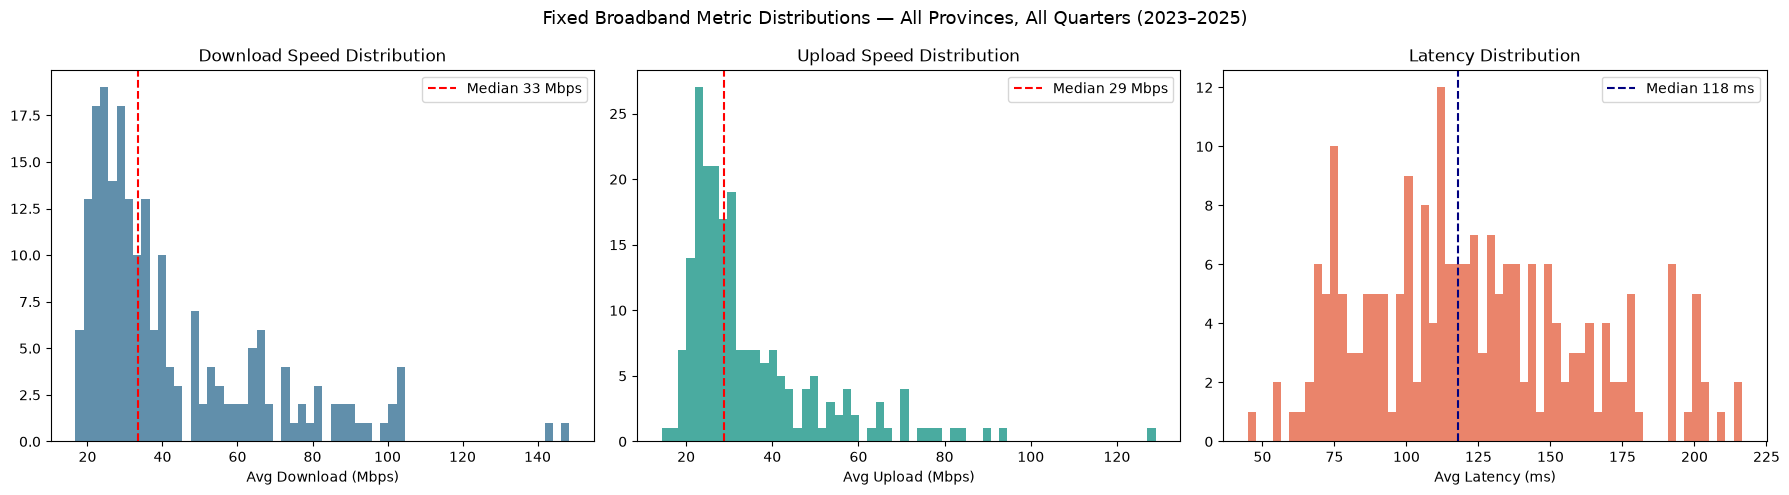

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      210.00      210.00         210.00       210.00
mean        42.17       34.85         122.83     37543.79
std         24.08       16.42          38.22    171592.33
min         16.79       14.31          44.93       107.00
25%         25.20       24.41          92.53       954.25
50%         33.37       28.88         117.87      1770.50
75%         52.55       39.86         148.63      5586.75
max        148.52      129.00         216.46   1873991.00


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

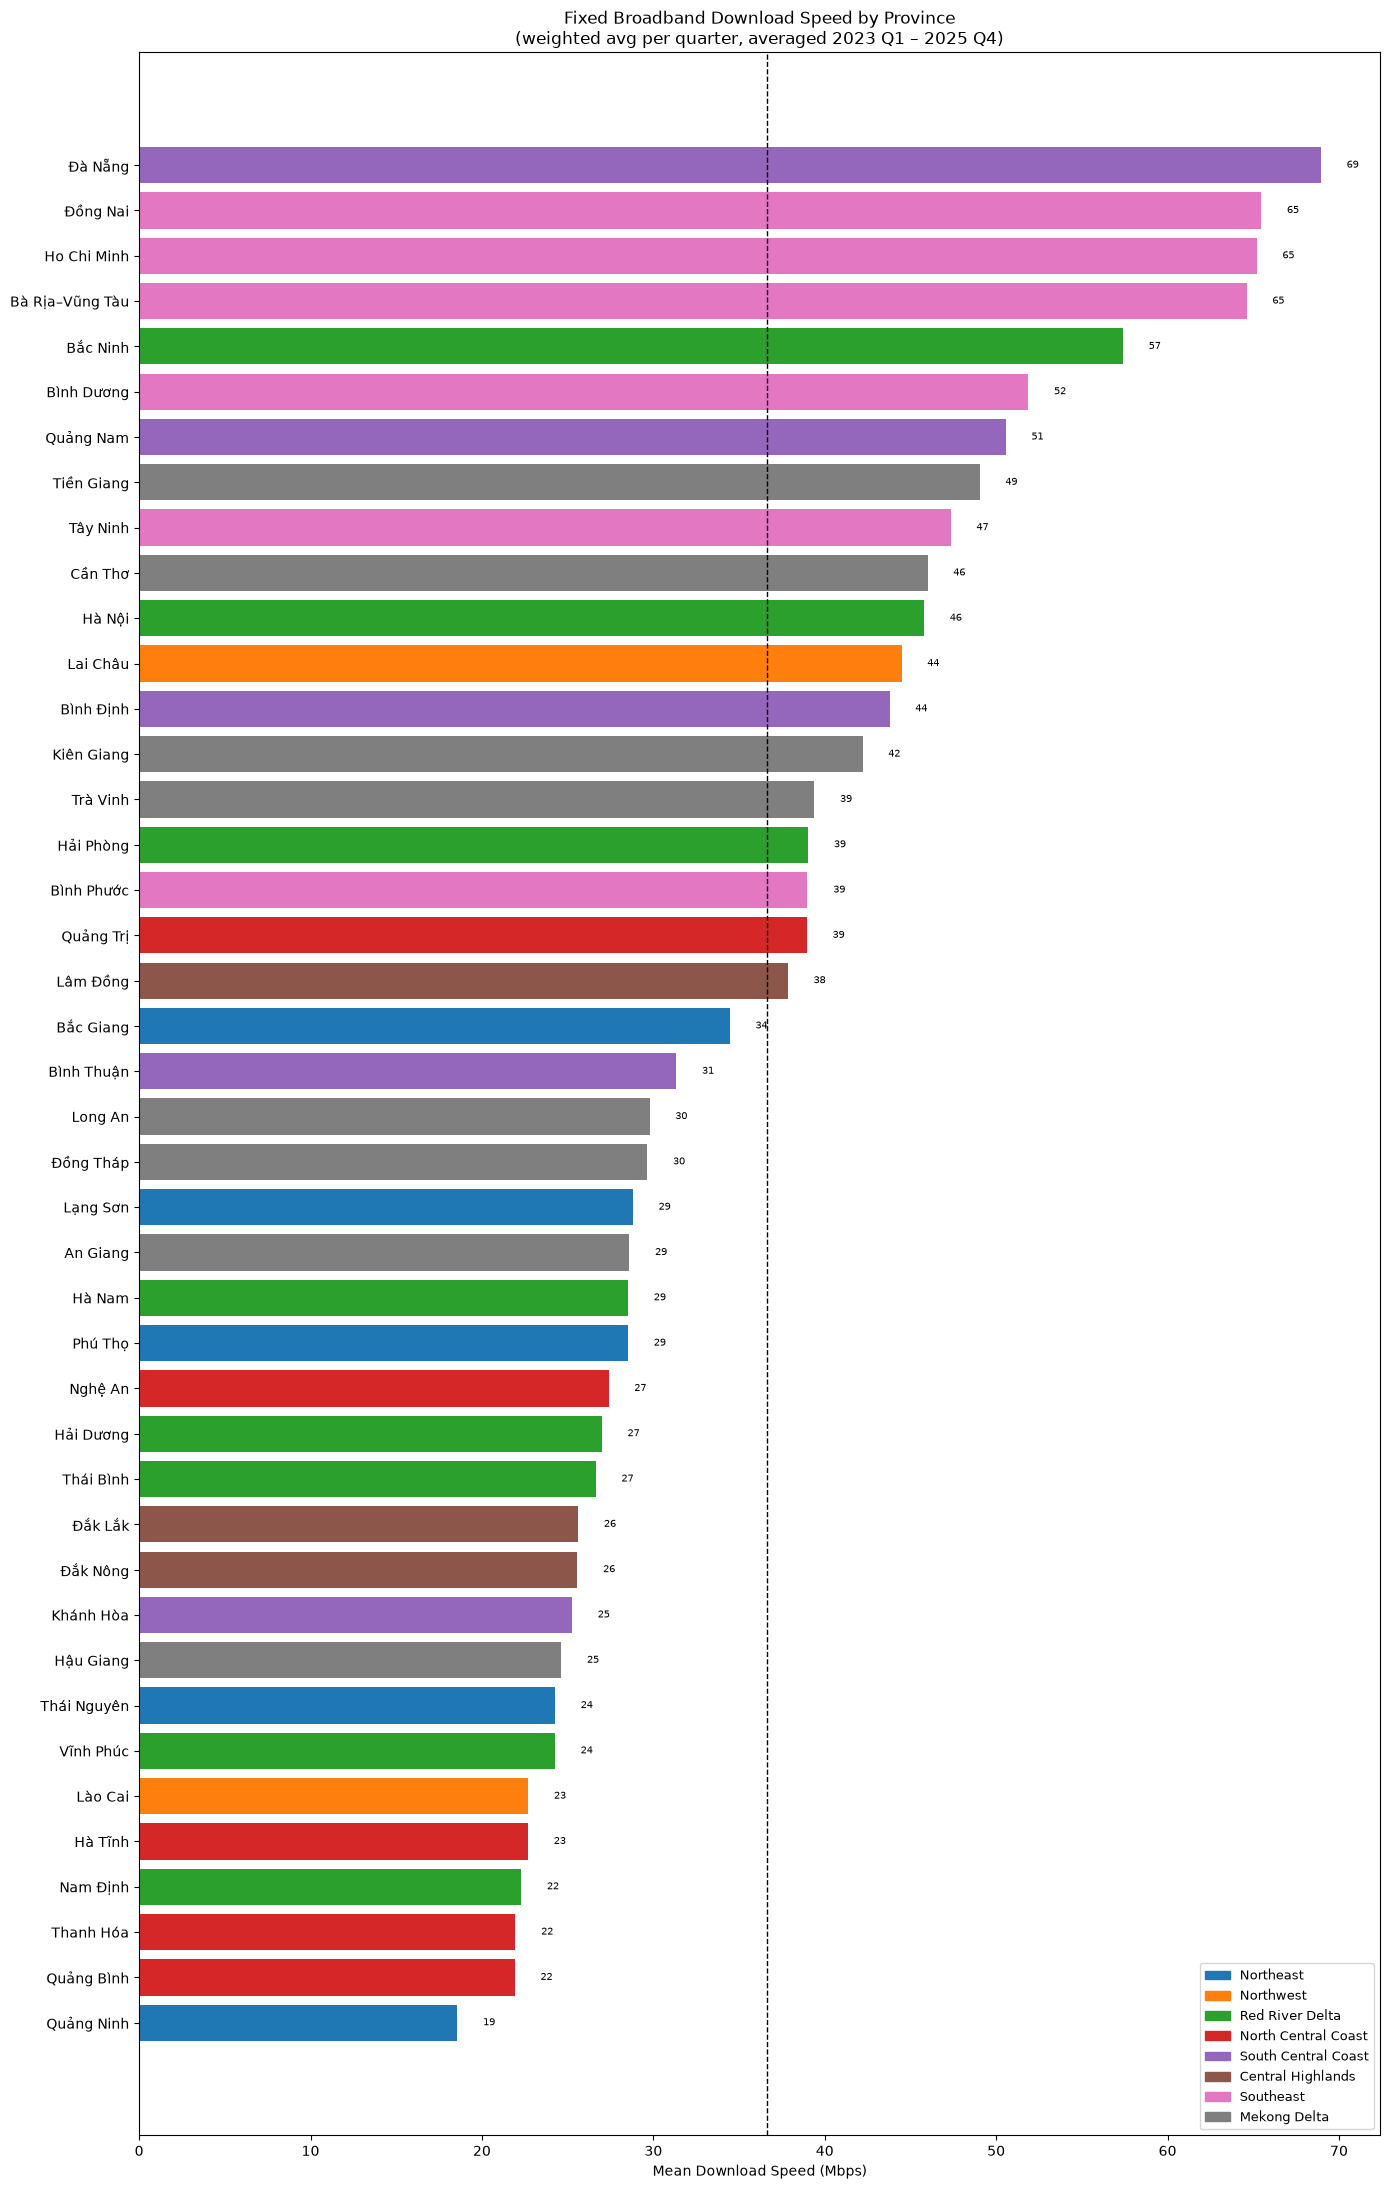

In [11]:
region_colors = {
    'Northeast': '#1f77b4',
    'Northwest': '#ff7f0e',
    'Red River Delta': '#2ca02c',
    'North Central Coast': '#d62728',
    'South Central Coast': '#9467bd',
    'Central Highlands': '#8c564b',
    'Southeast': '#e377c2',
    'Mekong Delta': '#7f7f7f',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

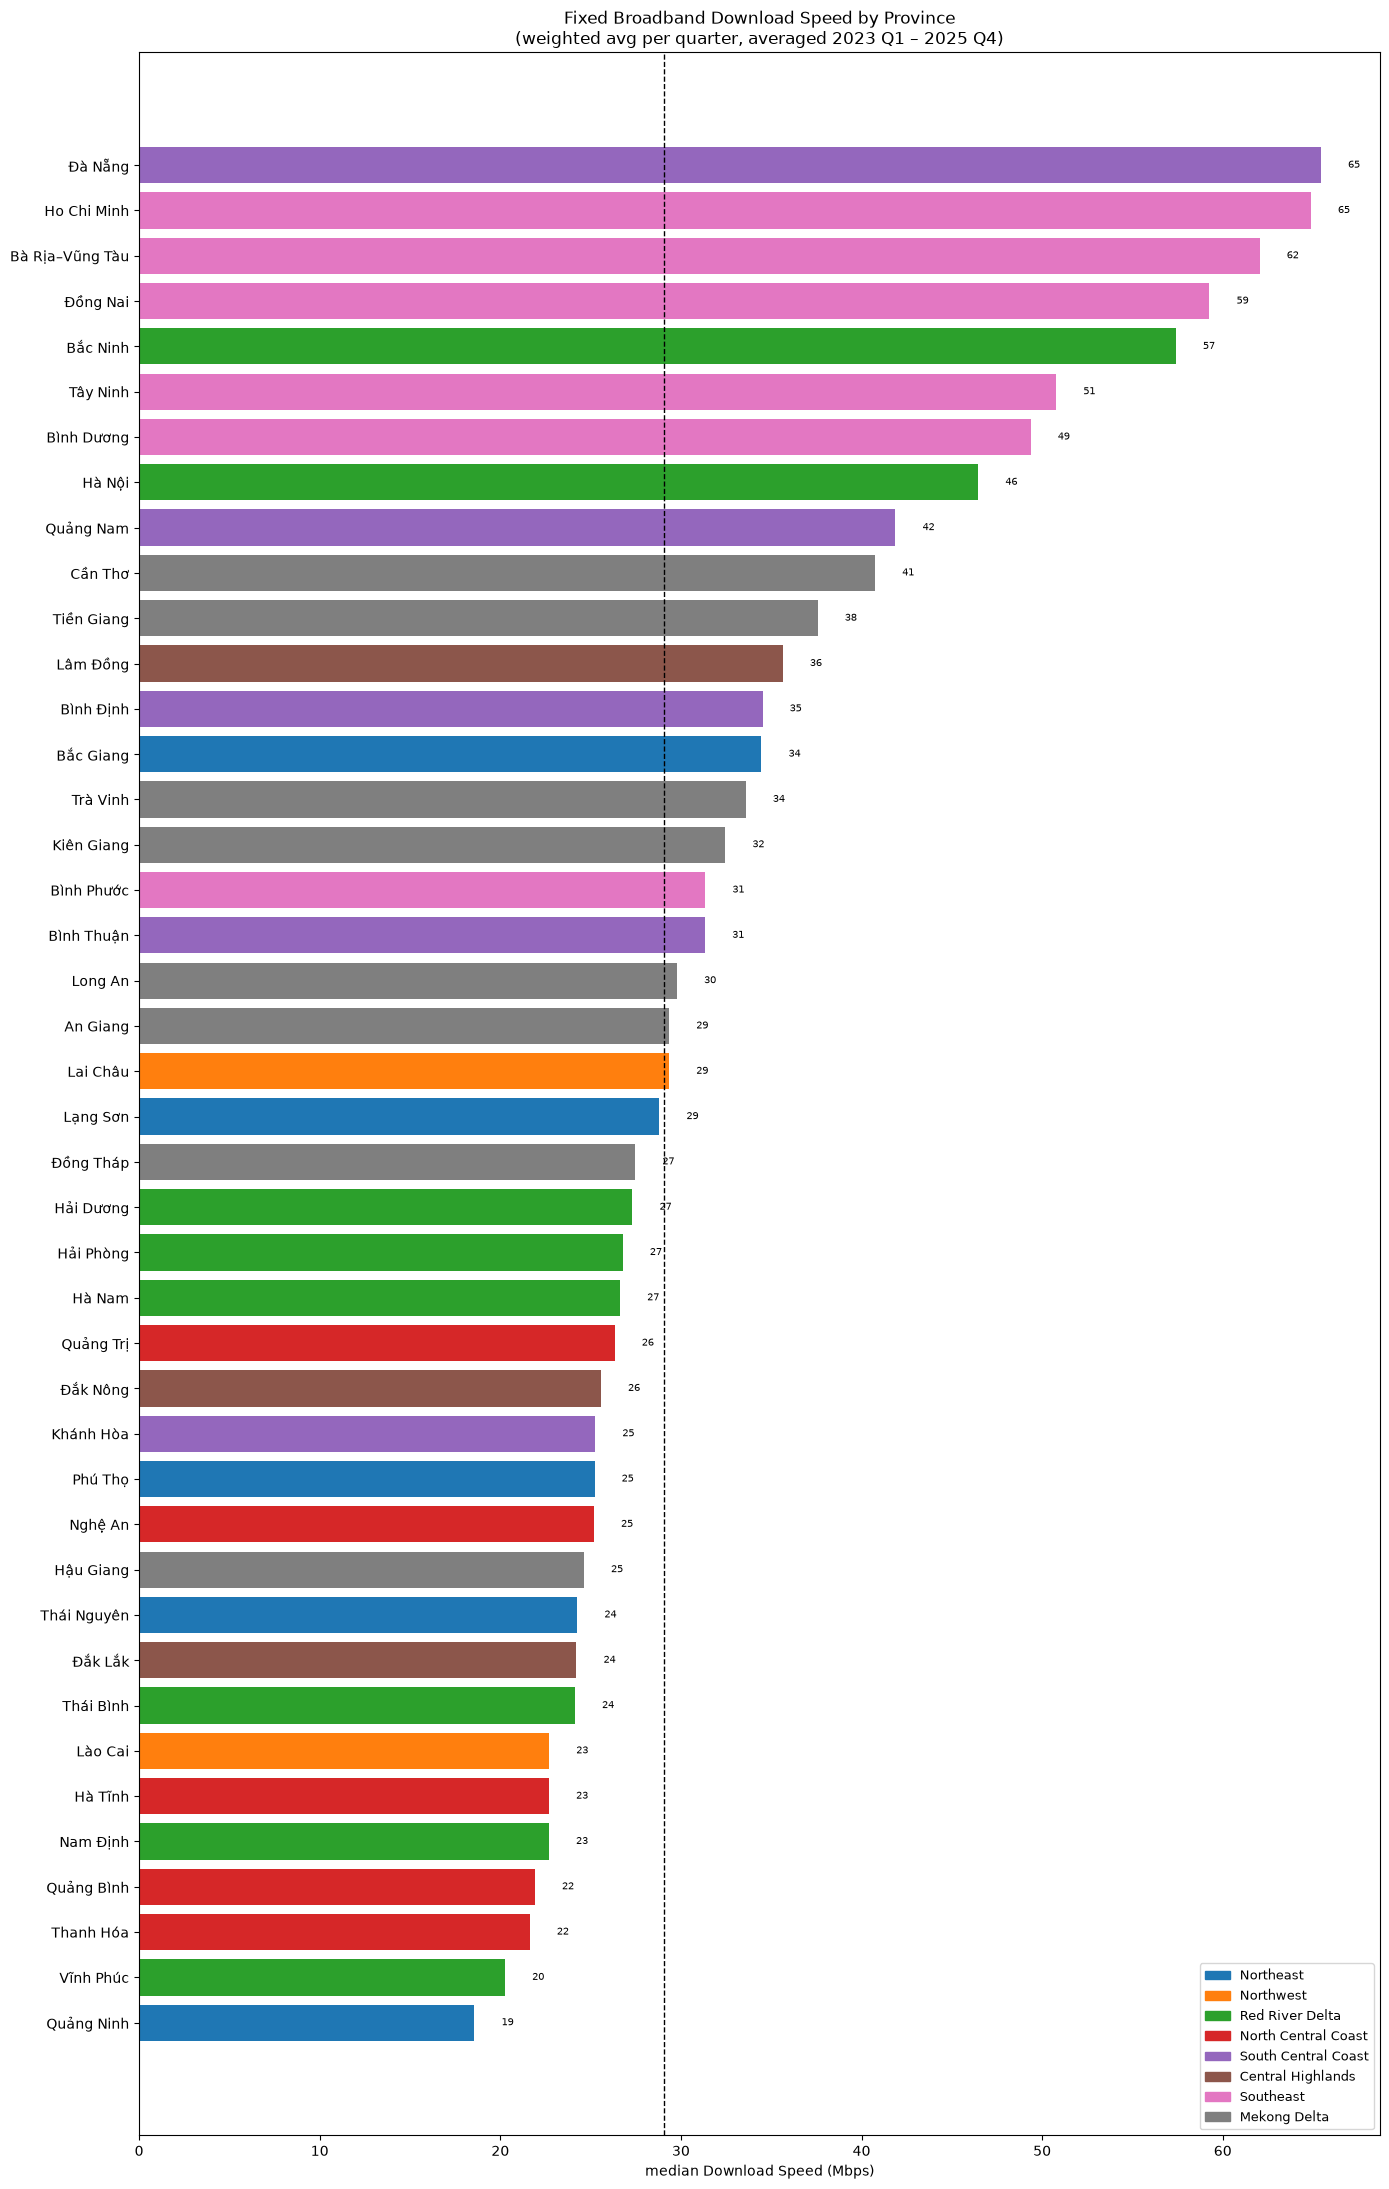

In [12]:
region_colors = {
    'Northeast': '#1f77b4',
    'Northwest': '#ff7f0e',
    'Red River Delta': '#2ca02c',
    'North Central Coast': '#d62728',
    'South Central Coast': '#9467bd',
    'Central Highlands': '#8c564b',
    'Southeast': '#e377c2',
    'Mekong Delta': '#7f7f7f',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

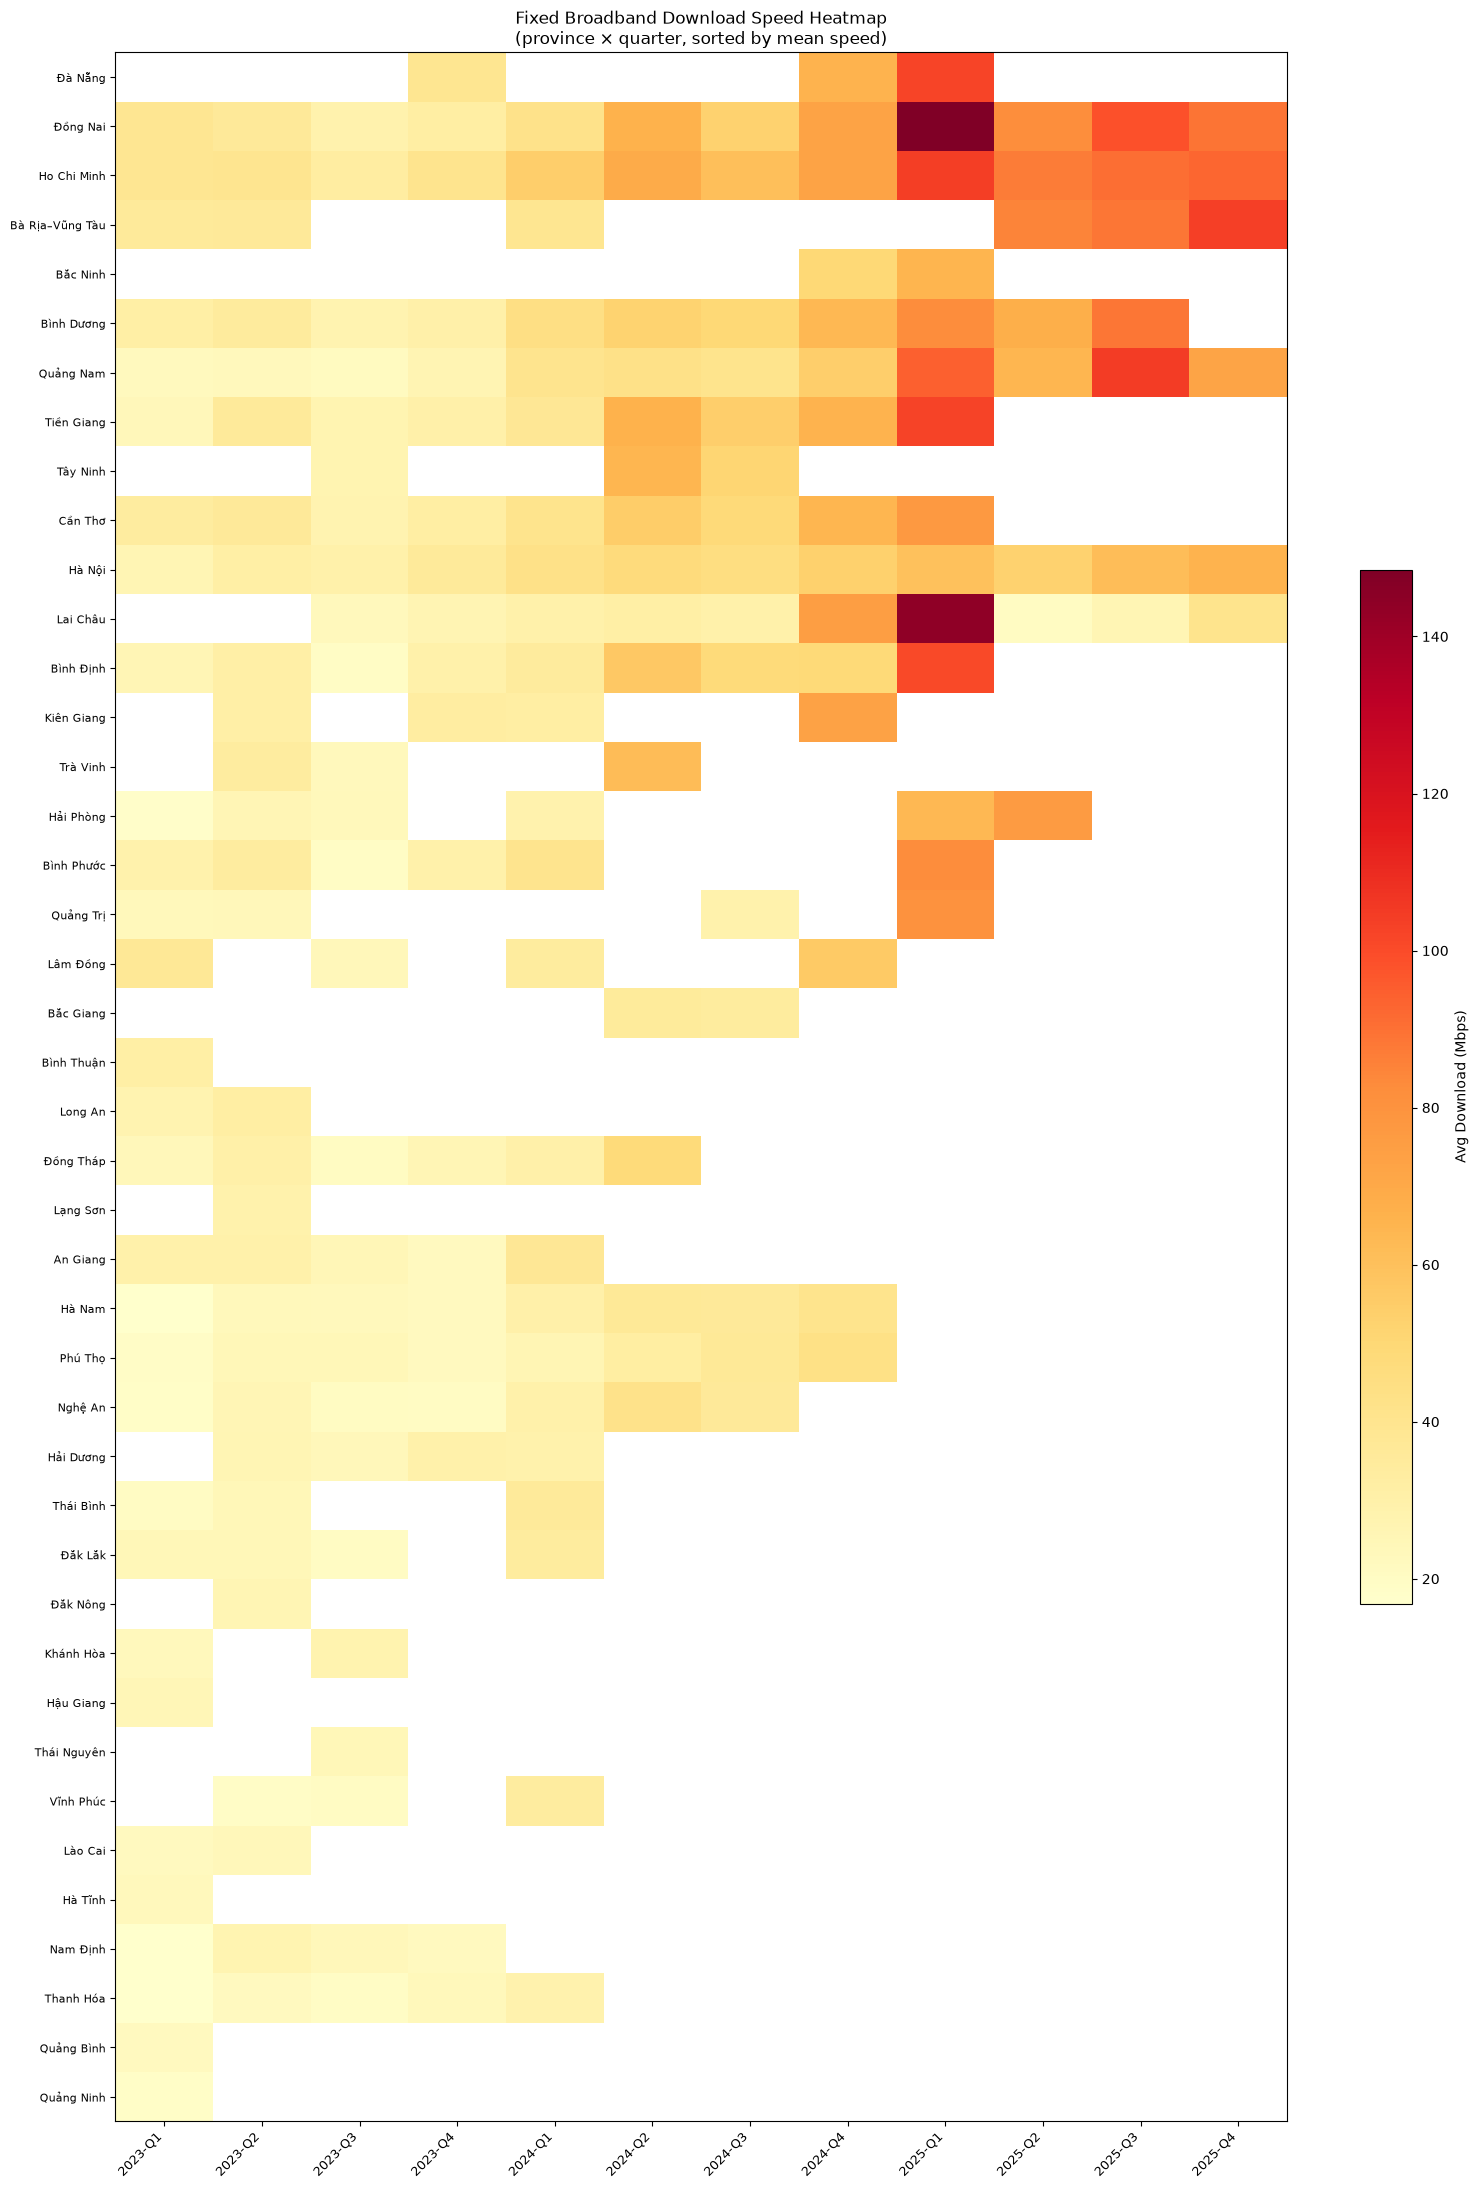

In [13]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

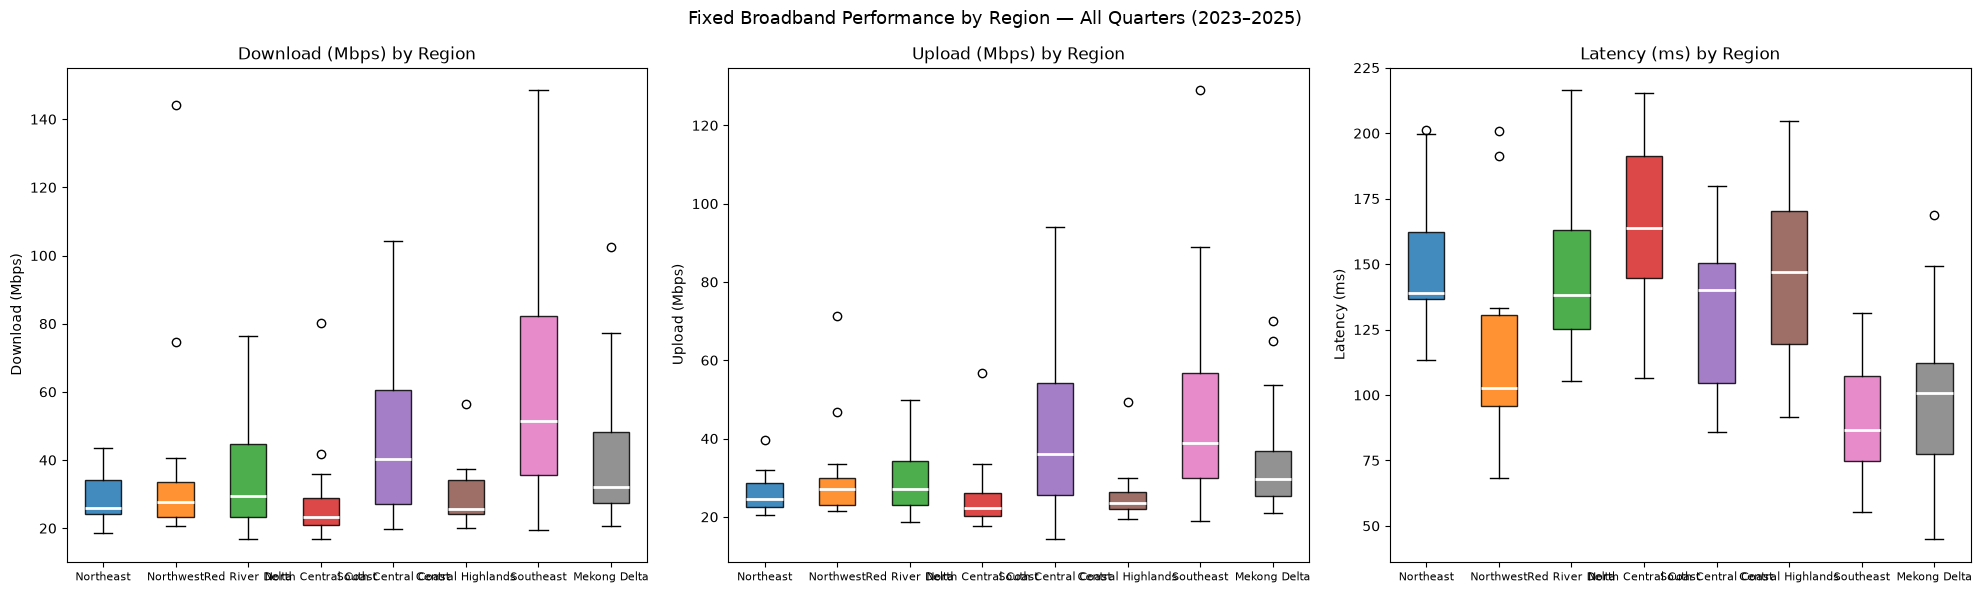

In [14]:
region_order = ['Northeast', 'Northwest', 'Red River Delta', 'North Central Coast', 'South Central Coast', 'Central Highlands', 'Southeast', 'Mekong Delta']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

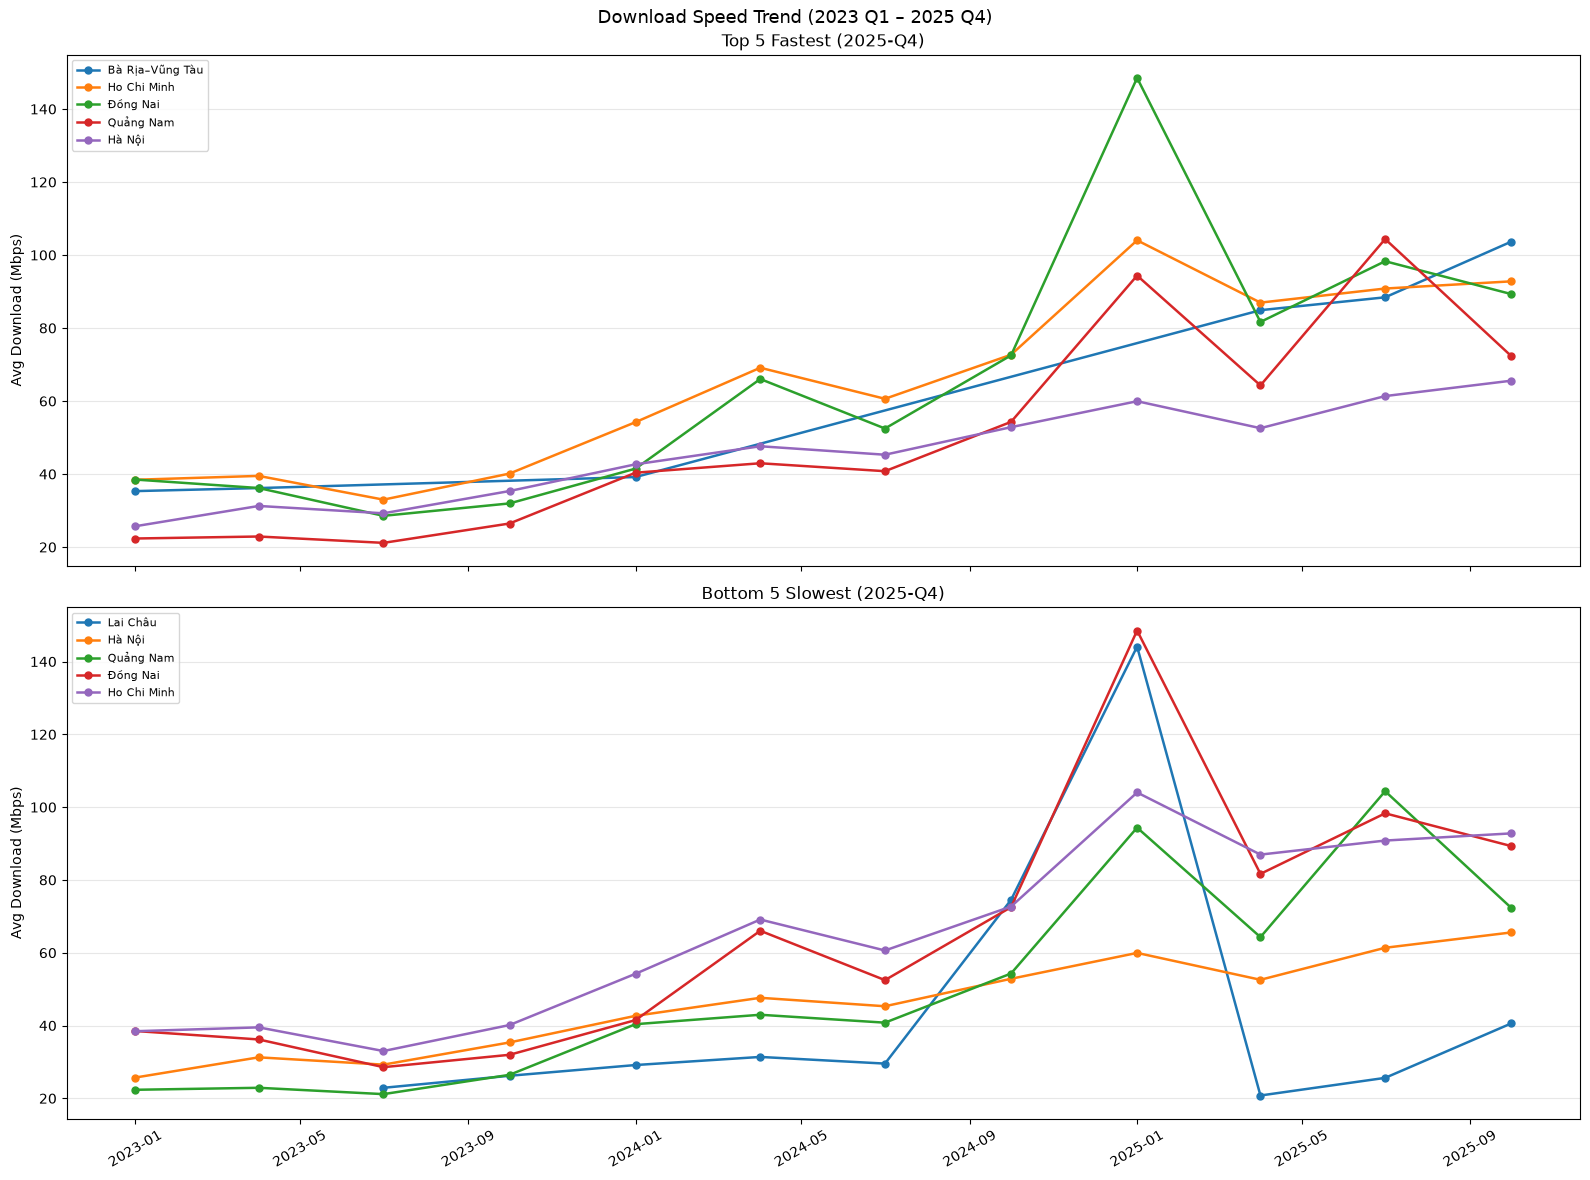

In [15]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

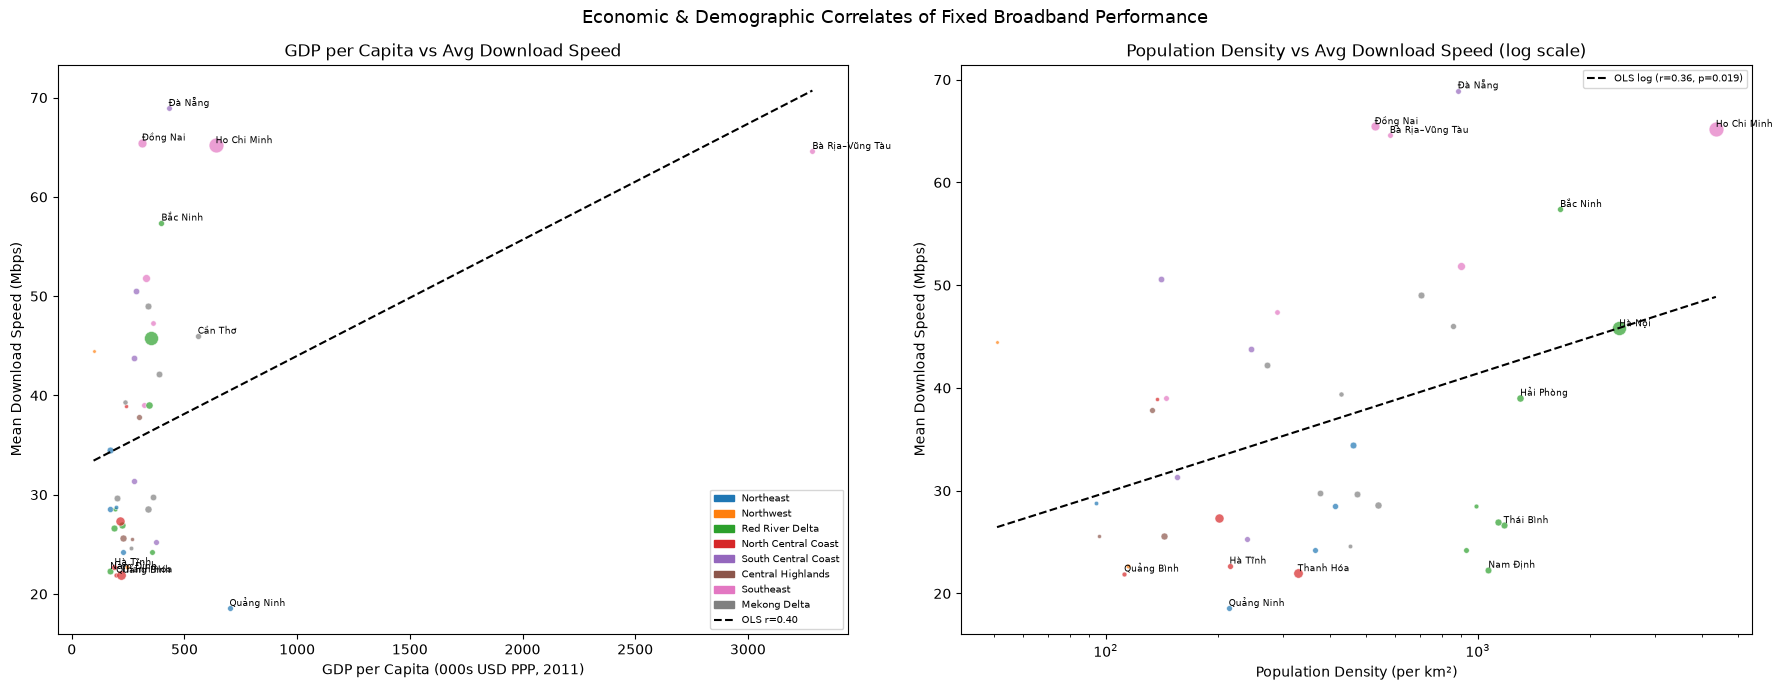

Pearson r (GDP vs download):     0.405  p=0.0078
Pearson r (log density vs download): 0.360  p=0.0193


In [16]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD PPP, 2011)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together


In [17]:
import statsmodels.formula.api as smf

model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

terms = []
if model_df['log_gdp'].nunique() > 1:
    terms.append('log_gdp')
if model_df['log_density'].nunique() > 1:
    terms.append('log_density')
if model_df['internet_tier'].nunique() > 1:
    terms.append("C(internet_tier)")
if model_df['region'].nunique() > 1:
    terms.append('C(region)')

formula = 'mean_dl ~ ' + ' + '.join(terms)
mv_model = smf.ols(formula, data=model_df).fit()
print(mv_model.summary())

print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     3.581
Date:                Tue, 14 Jul 2026   Prob (F-statistic):            0.00243
Time:                        08:15:37   Log-Likelihood:                -150.16
No. Observations:                  42   AIC:                             326.3
Df Residuals:                      29   BIC:                             348.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

### 9. Upload/Download Ratio — Symmetry Check

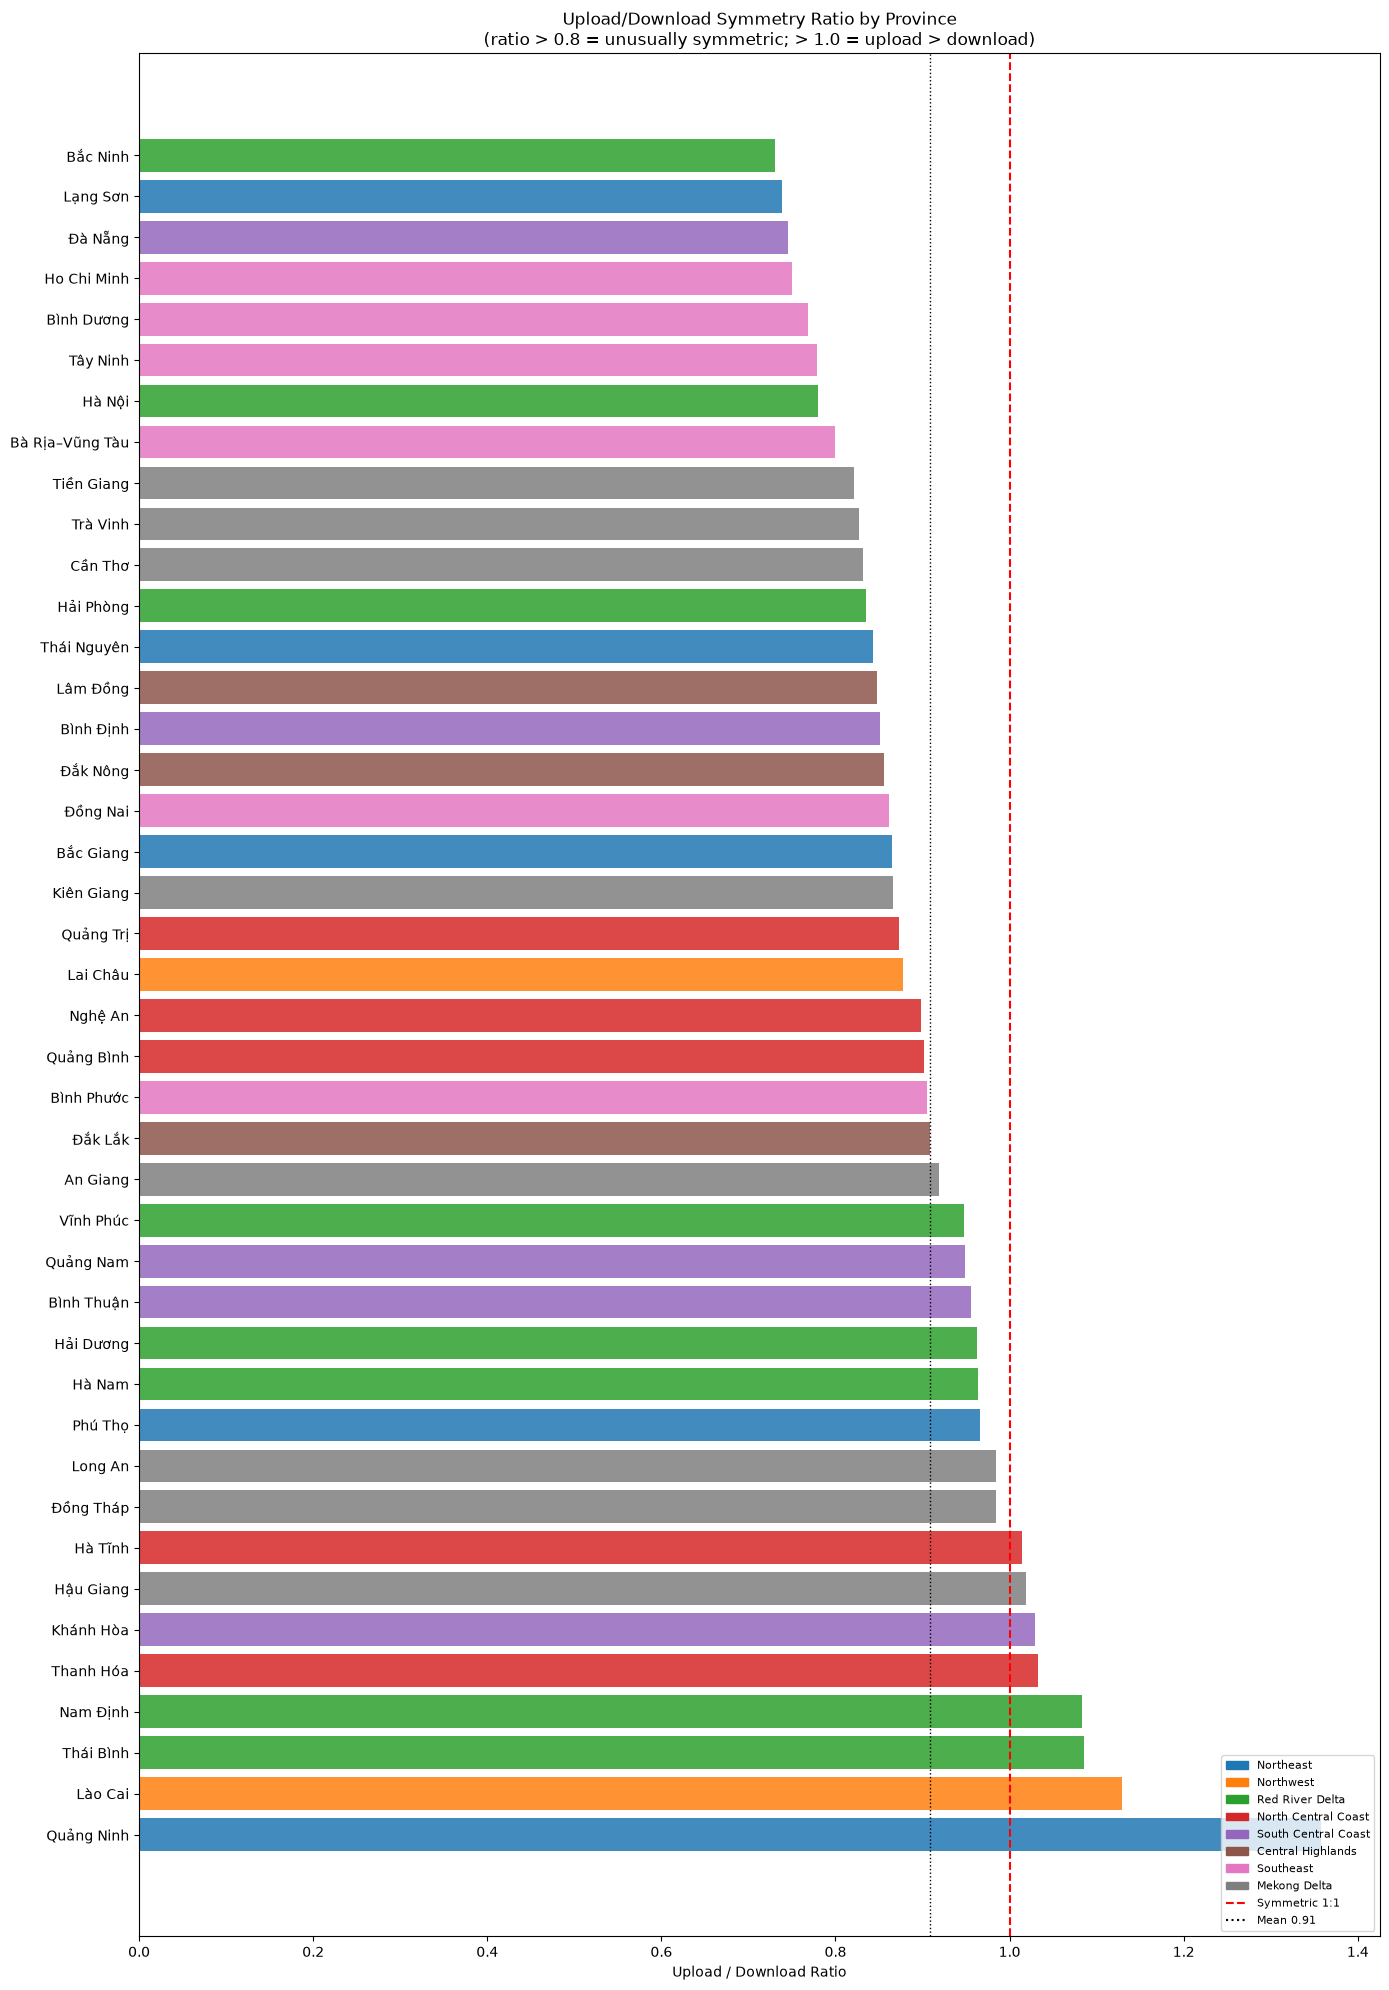

Provinces with UL/DL ratio > 0.8 (34):
       name              region  ul_dl_ratio
 Quảng Ninh           Northeast     1.357625
    Lào Cai           Northwest     1.129445
  Thái Bình     Red River Delta     1.084913
   Nam Định     Red River Delta     1.082755
  Thanh Hóa North Central Coast     1.032222
  Khánh Hòa South Central Coast     1.029464
  Hậu Giang        Mekong Delta     1.018295
    Hà Tĩnh North Central Coast     1.014670
  Đồng Tháp        Mekong Delta     0.984370
    Long An        Mekong Delta     0.984282
    Phú Thọ           Northeast     0.965586
     Hà Nam     Red River Delta     0.963573
  Hải Dương     Red River Delta     0.962717
 Bình Thuận South Central Coast     0.955306
  Quảng Nam South Central Coast     0.948909
  Vĩnh Phúc     Red River Delta     0.947309
   An Giang        Mekong Delta     0.918386
    Đắk Lắk   Central Highlands     0.908638
 Bình Phước           Southeast     0.905416
 Quảng Bình North Central Coast     0.902030
    Nghệ An Nort

In [18]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Anomaly Detection — Province Flags

In [19]:
# === ANOMALY DETECTION (recalibrated from actual data) ===
# National mean UL/DL ratio = 0.852 → flag only clear outliers (z-score based)
# Tier medians are compressed: T1=282, T2=247, T3=246, T4=229 Mbps
# Thresholds set based on observed distributions

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


### 12. Full Province Summary Table

In [20]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

           name              region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
        Đà Nẵng South Central Coast              1    68.94    49.21    119.09         0.74    71021.67                429834.96
       Đồng Nai           Southeast              2    65.46    55.33     78.64         0.86    12336.33                311341.31
    Ho Chi Minh           Southeast              1    65.20    47.48     96.65         0.75   245499.17                638474.09
Bà Rịa–Vũng Tàu           Southeast              1    64.61    50.51     92.14         0.80     3358.83               3286254.54
       Bắc Ninh     Red River Delta              1    57.40    40.71    130.27         0.73    21293.00                397659.74
     Bình Dương           Southeast              2    51.88    38.09     85.95         0.77     5267.64                327276.61
      Quảng Nam South Central Coast              2    50.56    45.64    144.15         0.95     6

### 13. UL/DL Symmetry — Fiber Penetration Evidence

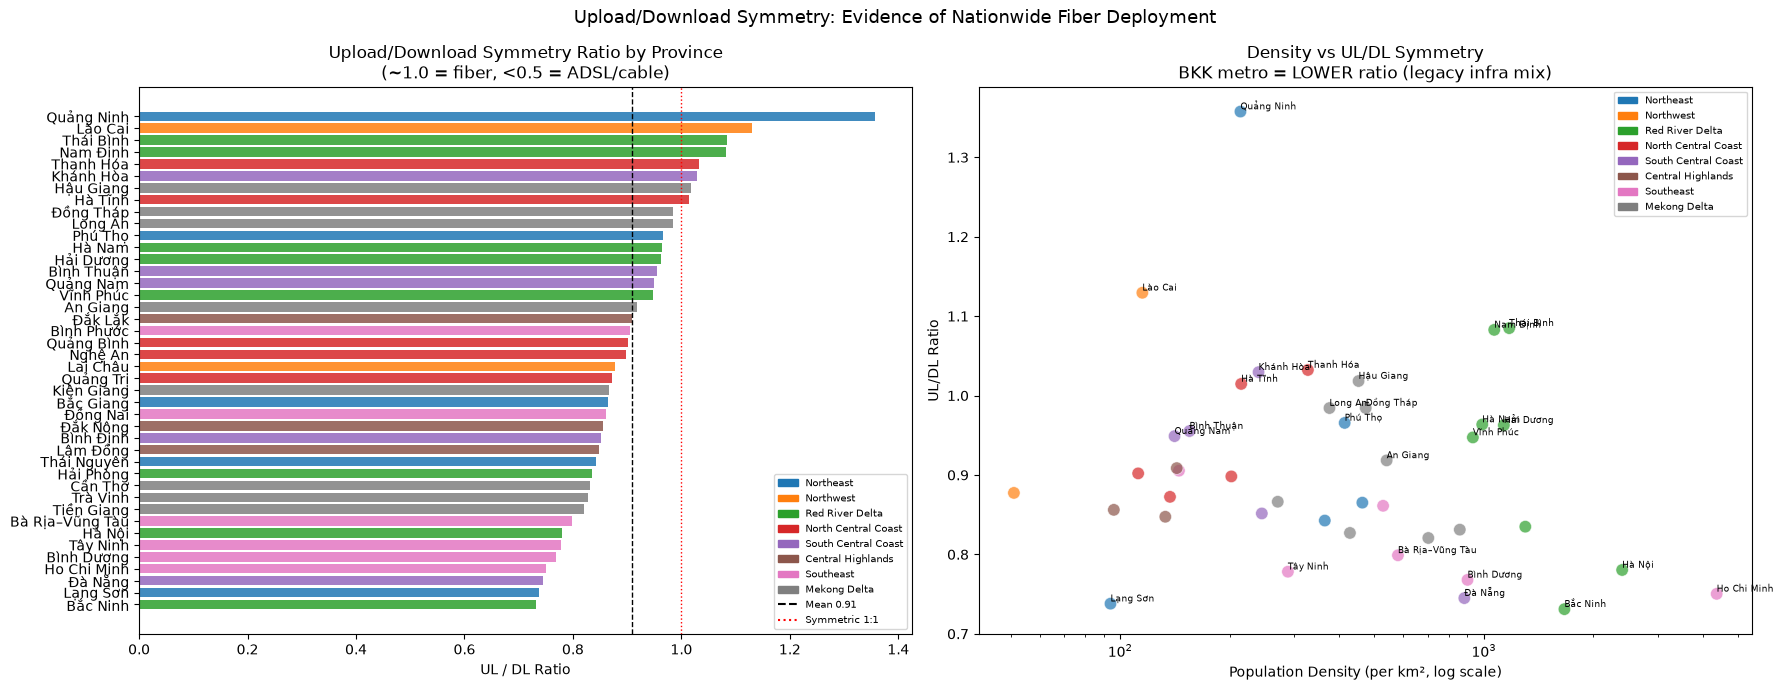

Provinces ratio > 0.90: 20 (near-perfect fiber)
Provinces ratio > 0.80: 34 out of 42
Southeast min ratio: 0.750
Northwest max ratio: 1.129


In [21]:
# Near-symmetric UL/DL often indicates fiber (GPON/FTTH ~1:1) vs legacy copper (ADSL ~0.1-0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nBKK metro = LOWER ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of {len(prov_mean)}")
print(f"{_top_region} min ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].min():.3f}")
print(f"{_bot_region} max ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

Provinces with reliable data in BOTH 2023-Q1 and 2025-Q4: 5 (of 42 provinces with any reliable data) — small n here because reliable NDT7 coverage decays sharply toward 2025.


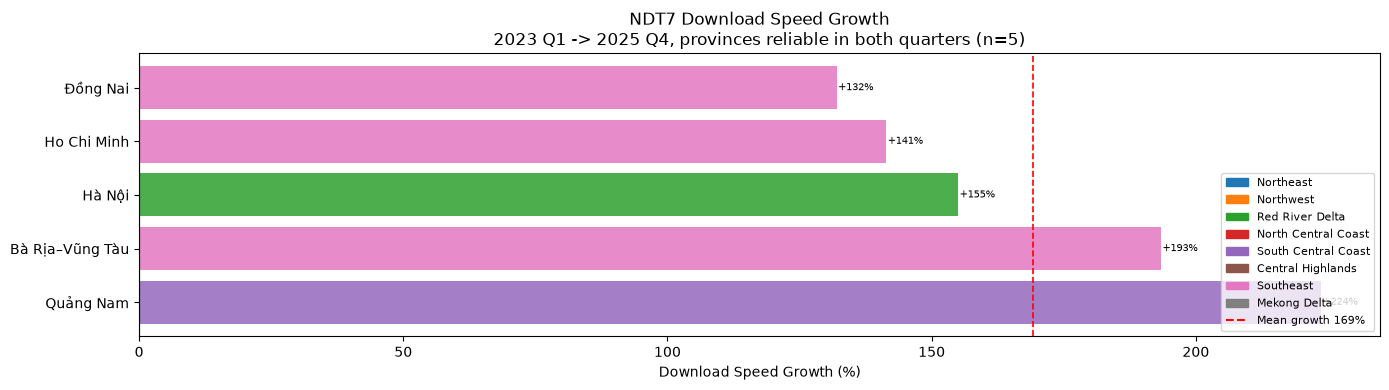

           name              region  internet_tier  pct_growth
      Quảng Nam South Central Coast              2  223.669634
Bà Rịa–Vũng Tàu           Southeast              1  193.379077
         Hà Nội     Red River Delta              1  155.003034
    Ho Chi Minh           Southeast              1  141.393599
       Đồng Nai           Southeast              2  131.997605


In [22]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)
print(f"Provinces with reliable data in BOTH 2023-Q1 and 2025-Q4: {len(growth)} "
      f"(of {master['name'].nunique()} provinces with any reliable data) — "
      "small n here because reliable NDT7 coverage decays sharply toward 2025.")

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

region_colors = {
    'Northeast': '#1f77b4', 'Northwest': '#ff7f0e', 'Red River Delta': '#2ca02c',
    'North Central Coast': '#d62728', 'South Central Coast': '#9467bd',
    'Central Highlands': '#8c564b', 'Southeast': '#e377c2', 'Mekong Delta': '#7f7f7f',
}

if len(growth_df):
    fig, ax = plt.subplots(figsize=(14, max(4, 0.5*len(growth_df))))
    colors = [region_colors.get(r,'gray') for r in growth_df['region']]
    bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
               label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
    for bar, val in zip(bars, growth_df['pct_growth']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:+.0f}%', va='center', fontsize=7)
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
              fontsize=8, loc='lower right')
    ax.set_xlabel('Download Speed Growth (%)')
    ax.set_title(f'NDT7 Download Speed Growth\n2023 Q1 -> 2025 Q4, provinces reliable in both quarters (n={len(growth_df)})', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/vietnam/20_growth_2023q1_2025q4.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(growth_df.sort_values('pct_growth', ascending=False)[['name','region','internet_tier','pct_growth']].to_string(index=False))
else:
    print("No province has reliable data in both 2023-Q1 and 2025-Q4 — cannot compute a paired growth figure.")


### 15. Deep Dive — The Divergent Ones

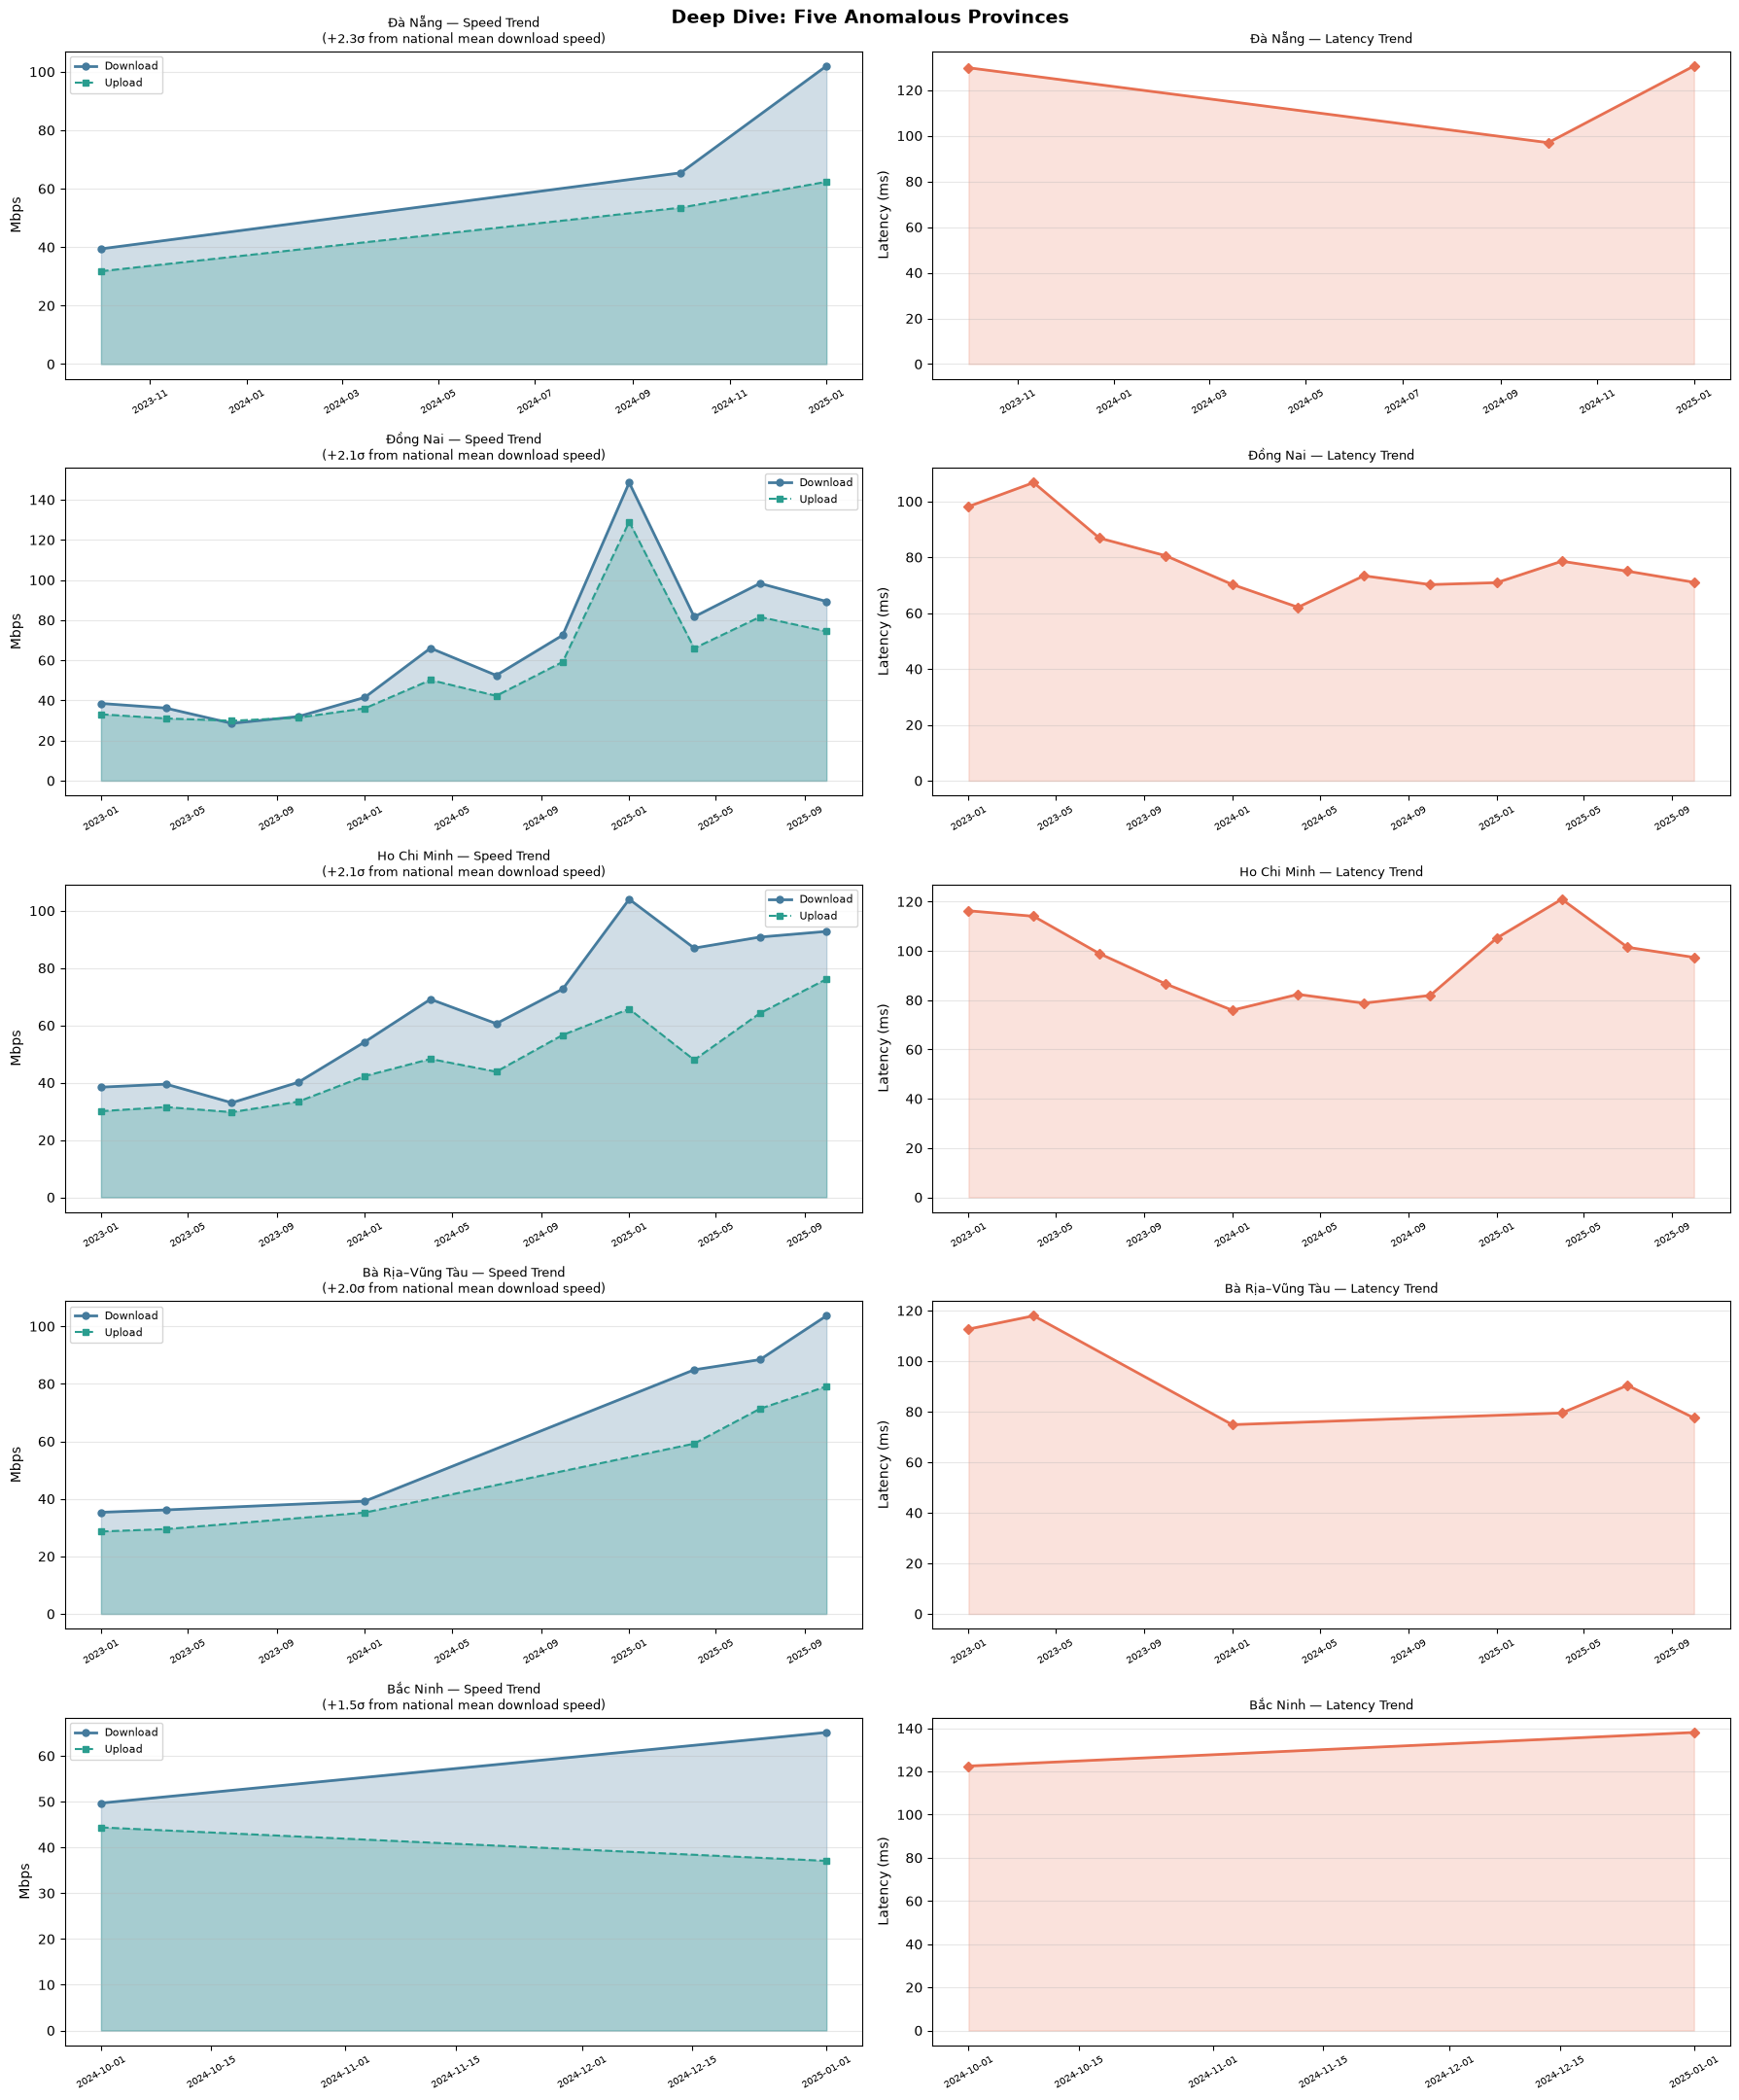

In [23]:
# Focus on the 5 most extreme performers (data-driven selection, no anomaly flags)
_pm = prov_mean.copy()
_pm['z'] = (_pm['mean_dl'] - _pm['mean_dl'].mean()) / _pm['mean_dl'].std()
_top_divergent_df = _pm.reindex(_pm['z'].abs().sort_values(ascending=False).index).head(5)
DIVERGENT = {
    row['name']: f"{row['z']:+.1f}σ from national mean download speed"
    for _, row in _top_divergent_df.iterrows()
}

fig, axes = plt.subplots(len(DIVERGENT), 2, figsize=(18, 22))

quarter_order = sorted(master['label'].unique())

for ax_row, (prov, note) in zip(axes, DIVERGENT.items()):
    df_p = master[master['name']==prov].sort_values('label')
    
    # Download + upload trend
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_d_mbps'], alpha=0.25, color='#457b9d')
    ax_row[0].plot(df_p['period_start'], df_p['avg_d_mbps'], 'o-', color='#457b9d', label='Download', lw=2, markersize=5)
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_u_mbps'], alpha=0.25, color='#2a9d8f')
    ax_row[0].plot(df_p['period_start'], df_p['avg_u_mbps'], 's--', color='#2a9d8f', label='Upload', lw=1.5, markersize=4)
    ax_row[0].set_title(f'{prov} — Speed Trend\n({note})', fontsize=9)
    ax_row[0].set_ylabel('Mbps'); ax_row[0].legend(fontsize=8); ax_row[0].grid(axis='y', alpha=0.3)
    ax_row[0].tick_params(axis='x', rotation=30, labelsize=7)
    
    # Latency trend
    ax_row[1].plot(df_p['period_start'], df_p['avg_lat_ms_wt'], 'D-', color='#e76f51', lw=2, markersize=5)
    ax_row[1].fill_between(df_p['period_start'], df_p['avg_lat_ms_wt'], alpha=0.2, color='#e76f51')
    ax_row[1].set_title(f'{prov} — Latency Trend', fontsize=9)
    ax_row[1].set_ylabel('Latency (ms)'); ax_row[1].grid(axis='y', alpha=0.3)
    ax_row[1].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Deep Dive: Five Anomalous Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/21_deep_dive_divergent.png', dpi=150, bbox_inches='tight')
plt.show()


### 16. EDA Key Findings Summary

## Key Findings from EDA

- **Coverage is the binding constraint, not speed.** Of 64 provinces in the reference table, 63 have
  *any* NDT7 test volume (Côn Đảo, a small island district, has none), but only 42 ever clear the
  `is_reliable` bar (≥100 tests & ≥5 tiles) in at least one quarter, and reliable province-quarters
  drop from 30 provinces in 2023-Q1 to just 6 by 2025-Q4 (28.6% reliable overall). Any NDT7-Vietnam
  result — including everything below — should be read as "42 provinces, weighted toward 2023" rather
  than "all of Vietnam, 2023-2025".
- **Speed distribution:** mean download 42.2 Mbps, median 33.4 Mbps across reliable province-quarters
  — an order of magnitude below Ookla's Vietnam fixed-broadband mean (~135 Mbps from the cross-country
  comparison notebook), consistent with NDT7's passive/background methodology under-reporting relative
  to Ookla's active, user-initiated tests (MacMillan et al. 2023).
- **GDP correlates with speed here — unlike Ookla's Vietnam result.** Pearson r=0.405 (p=0.008) for
  GDP vs download, r=0.360 (p=0.019) for log-density vs download — both statistically significant.
  This is a real divergence from the Ookla Vietnam notebook, where GDP was *not* a significant
  predictor (r=0.10, p=0.43). Worth flagging directly in the Ookla-vs-NDT7 cross-validation: the two
  sources don't just disagree on magnitude, they disagree on whether GDP predicts speed at all —
  plausibly because the reliable NDT7 subset (42 provinces, coverage-biased) isn't a random sample of
  the same population Ookla measures.
- **Multivariate model is noisier:** R²=0.597 (adj. R²=0.430) for GDP + density + tier + region
  together — much weaker than Ookla Vietnam's 0.756, expected given roughly a third of the reliable
  sample size.
- **UL/DL ratio suggests widespread fiber:** 34 of 42 provinces (81%) have a ratio > 0.8, and 20 (48%)
  exceed 0.9 — consistent with the fiber-symmetric signature Ookla also finds for Vietnam.
- **Growth trend is unreliable — sample too small to interpret.** Only 5 provinces have reliable data
  in both 2023-Q1 and 2025-Q4 (out of 42 with any reliable data), a direct consequence of the coverage
  decay above. The growth figures in section 14 are shown for completeness, not as a national trend.
- **Most divergent provinces:** Đà Nẵng (fast for its tier/GDP, high test coverage) and Quảng Ninh
  (underperforms Tier 1 expectations by ~59%) top the composite divergence leaderboard — both worth a
  qualitative look in any follow-up write-up.


---

In [24]:
from scipy import stats as scipy_stats

divergent_df = (
    master.groupby(['name', 'region'])
    .agg(
        mean_dl=('avg_d_mbps', 'mean'),
        mean_ul=('avg_u_mbps', 'mean'),
        mean_lat=('avg_lat_ms_wt', 'mean'),
        mean_tests=('total_tests', 'mean'),
    )
    .reset_index()
)

temp_std = master.groupby('name')['avg_d_mbps'].std().rename('std_dl')
divergent_df = divergent_df.merge(temp_std, on='name', how='left')
divergent_df['cv_dl'] = divergent_df['std_dl'] / divergent_df['mean_dl']

divergent_df = divergent_df.merge(
    prov_ref[['province_en','pop_2024','density_per_km2',
              'gdp_per_capita_thb_2021','internet_tier','area_km2']]
    .rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

divergent_df['ul_dl_ratio']        = divergent_df['mean_ul'] / divergent_df['mean_dl']
divergent_df['tests_per_1000_pop'] = divergent_df['mean_tests'] / divergent_df['pop_2024'] * 1_000

print(f"Provinces in analysis: {len(divergent_df)}")
print(divergent_df[['name','region','internet_tier','mean_dl','ul_dl_ratio','tests_per_1000_pop']].head(5).to_string(index=False))


Provinces in analysis: 42
           name              region  internet_tier   mean_dl  ul_dl_ratio  tests_per_1000_pop
       An Giang        Mekong Delta              1 28.599784     0.897527            0.870880
Bà Rịa–Vũng Tàu           Southeast              1 64.610622     0.781761            2.577769
     Bình Dương           Southeast              2 51.875555     0.734196            2.054460
     Bình Phước           Southeast              2 38.993129     0.936567            0.752094
     Bình Thuận South Central Coast              2 31.337100     0.955306            0.209613


In [25]:
# ── Dimension 1: Tier residual ─────────────────────────────────────────────────
tier_med = divergent_df.groupby('internet_tier')['mean_dl'].median()
divergent_df['tier_expected']   = divergent_df['internet_tier'].map(tier_med)
divergent_df['tier_residual']   = (divergent_df['mean_dl'] - divergent_df['tier_expected']) / divergent_df['tier_expected']
divergent_df['tier_residual_z'] = (divergent_df['tier_residual'] - divergent_df['tier_residual'].mean()) / divergent_df['tier_residual'].std()

# ── Dimension 2: GDP residual (OLS on log-GDP) ─────────────────────────────────
log_gdp = np.log(divergent_df['gdp_per_capita_thb_2021'])
if log_gdp.nunique() > 1:
    slope_g, int_g, r_g, p_g, _ = scipy_stats.linregress(log_gdp, divergent_df['mean_dl'])
    divergent_df['gdp_expected']   = int_g + slope_g * log_gdp
    divergent_df['gdp_residual']   = divergent_df['mean_dl'] - divergent_df['gdp_expected']
    divergent_df['gdp_residual_z'] = scipy_stats.zscore(divergent_df['gdp_residual'])
else:
    # GDP per capita uniform across regions (e.g. Singapore: national-only data) — dimension contributes nothing
    slope_g, int_g, r_g, p_g = 0.0, divergent_df['mean_dl'].mean(), float('nan'), float('nan')
    divergent_df['gdp_expected']   = int_g
    divergent_df['gdp_residual']   = 0.0
    divergent_df['gdp_residual_z'] = 0.0

# ── Dimension 3: Density residual (OLS on log-density) ────────────────────────
log_den = np.log1p(divergent_df['density_per_km2'])
slope_d, int_d, r_d, p_d, _ = scipy_stats.linregress(log_den, divergent_df['mean_dl'])
divergent_df['den_expected']   = int_d + slope_d * log_den
divergent_df['den_residual_z'] = scipy_stats.zscore(divergent_df['mean_dl'] - divergent_df['den_expected'])

# ── Dimension 4: Regional z-score (speed within region) ───────────────────────
divergent_df['regional_z'] = divergent_df.groupby('region')['mean_dl'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 5: UL/DL ratio z-score ──────────────────────────────────────────
divergent_df['ratio_z'] = scipy_stats.zscore(divergent_df['ul_dl_ratio'])

# ── Dimension 6: Within-region latency z-score ────────────────────────────────
divergent_df['lat_regional_z'] = divergent_df.groupby('region')['mean_lat'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 7: Coverage z-score (tests per 1000 pop) ────────────────────────
divergent_df['coverage_z'] = scipy_stats.zscore(divergent_df['tests_per_1000_pop'])

# ── Composite divergence score (sum of absolute z-scores) ──────────────────────
divergent_df['divergence_score'] = (
    np.abs(divergent_df['tier_residual_z']) +
    np.abs(divergent_df['gdp_residual_z']) +
    np.abs(divergent_df['den_residual_z']) +
    np.abs(divergent_df['regional_z']) +
    np.abs(divergent_df['ratio_z']) +
    np.abs(divergent_df['lat_regional_z']) +
    np.abs(divergent_df['coverage_z'])
)

print(f"GDP-speed OLS:     r = {r_g:.3f}, slope = {slope_g:.2f} Mbps per log-unit GDP")
print(f"Density-speed OLS: r = {r_d:.3f}, slope = {slope_d:.2f} Mbps per log-unit density")
print()
print("Top 15 divergentest provinces:")
cols = ['name','region','internet_tier','mean_dl','divergence_score',
        'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']
print(divergent_df.nlargest(15,'divergence_score')[cols].to_string(index=False))


GDP-speed OLS:     r = 0.498, slope = 12.72 Mbps per log-unit GDP
Density-speed OLS: r = 0.360, slope = 5.06 Mbps per log-unit density

Top 15 divergentest provinces:
           name              region  internet_tier   mean_dl  divergence_score  gdp_residual_z  den_residual_z  regional_z   ratio_z  lat_regional_z  coverage_z
        Đà Nẵng South Central Coast              1 68.944808         14.050223        2.324827        2.217238    1.627532 -1.301282       -0.386208    4.564632
     Quảng Ninh           Northeast              1 18.569440         13.191280       -2.468737       -1.186371   -1.580481  3.541127        1.958360   -0.435643
       Đồng Nai           Southeast              2 65.462341          9.804471        2.377301        2.147545    0.965606 -0.312036       -1.687386   -0.111507
       Bắc Ninh     Red River Delta              1 57.399146          9.350638        1.430425        1.055885    2.028263 -1.334928       -1.822985    0.885986
    Ho Chi Minh           So

### 18. Tier vs Actual Speed — Expectation Gap

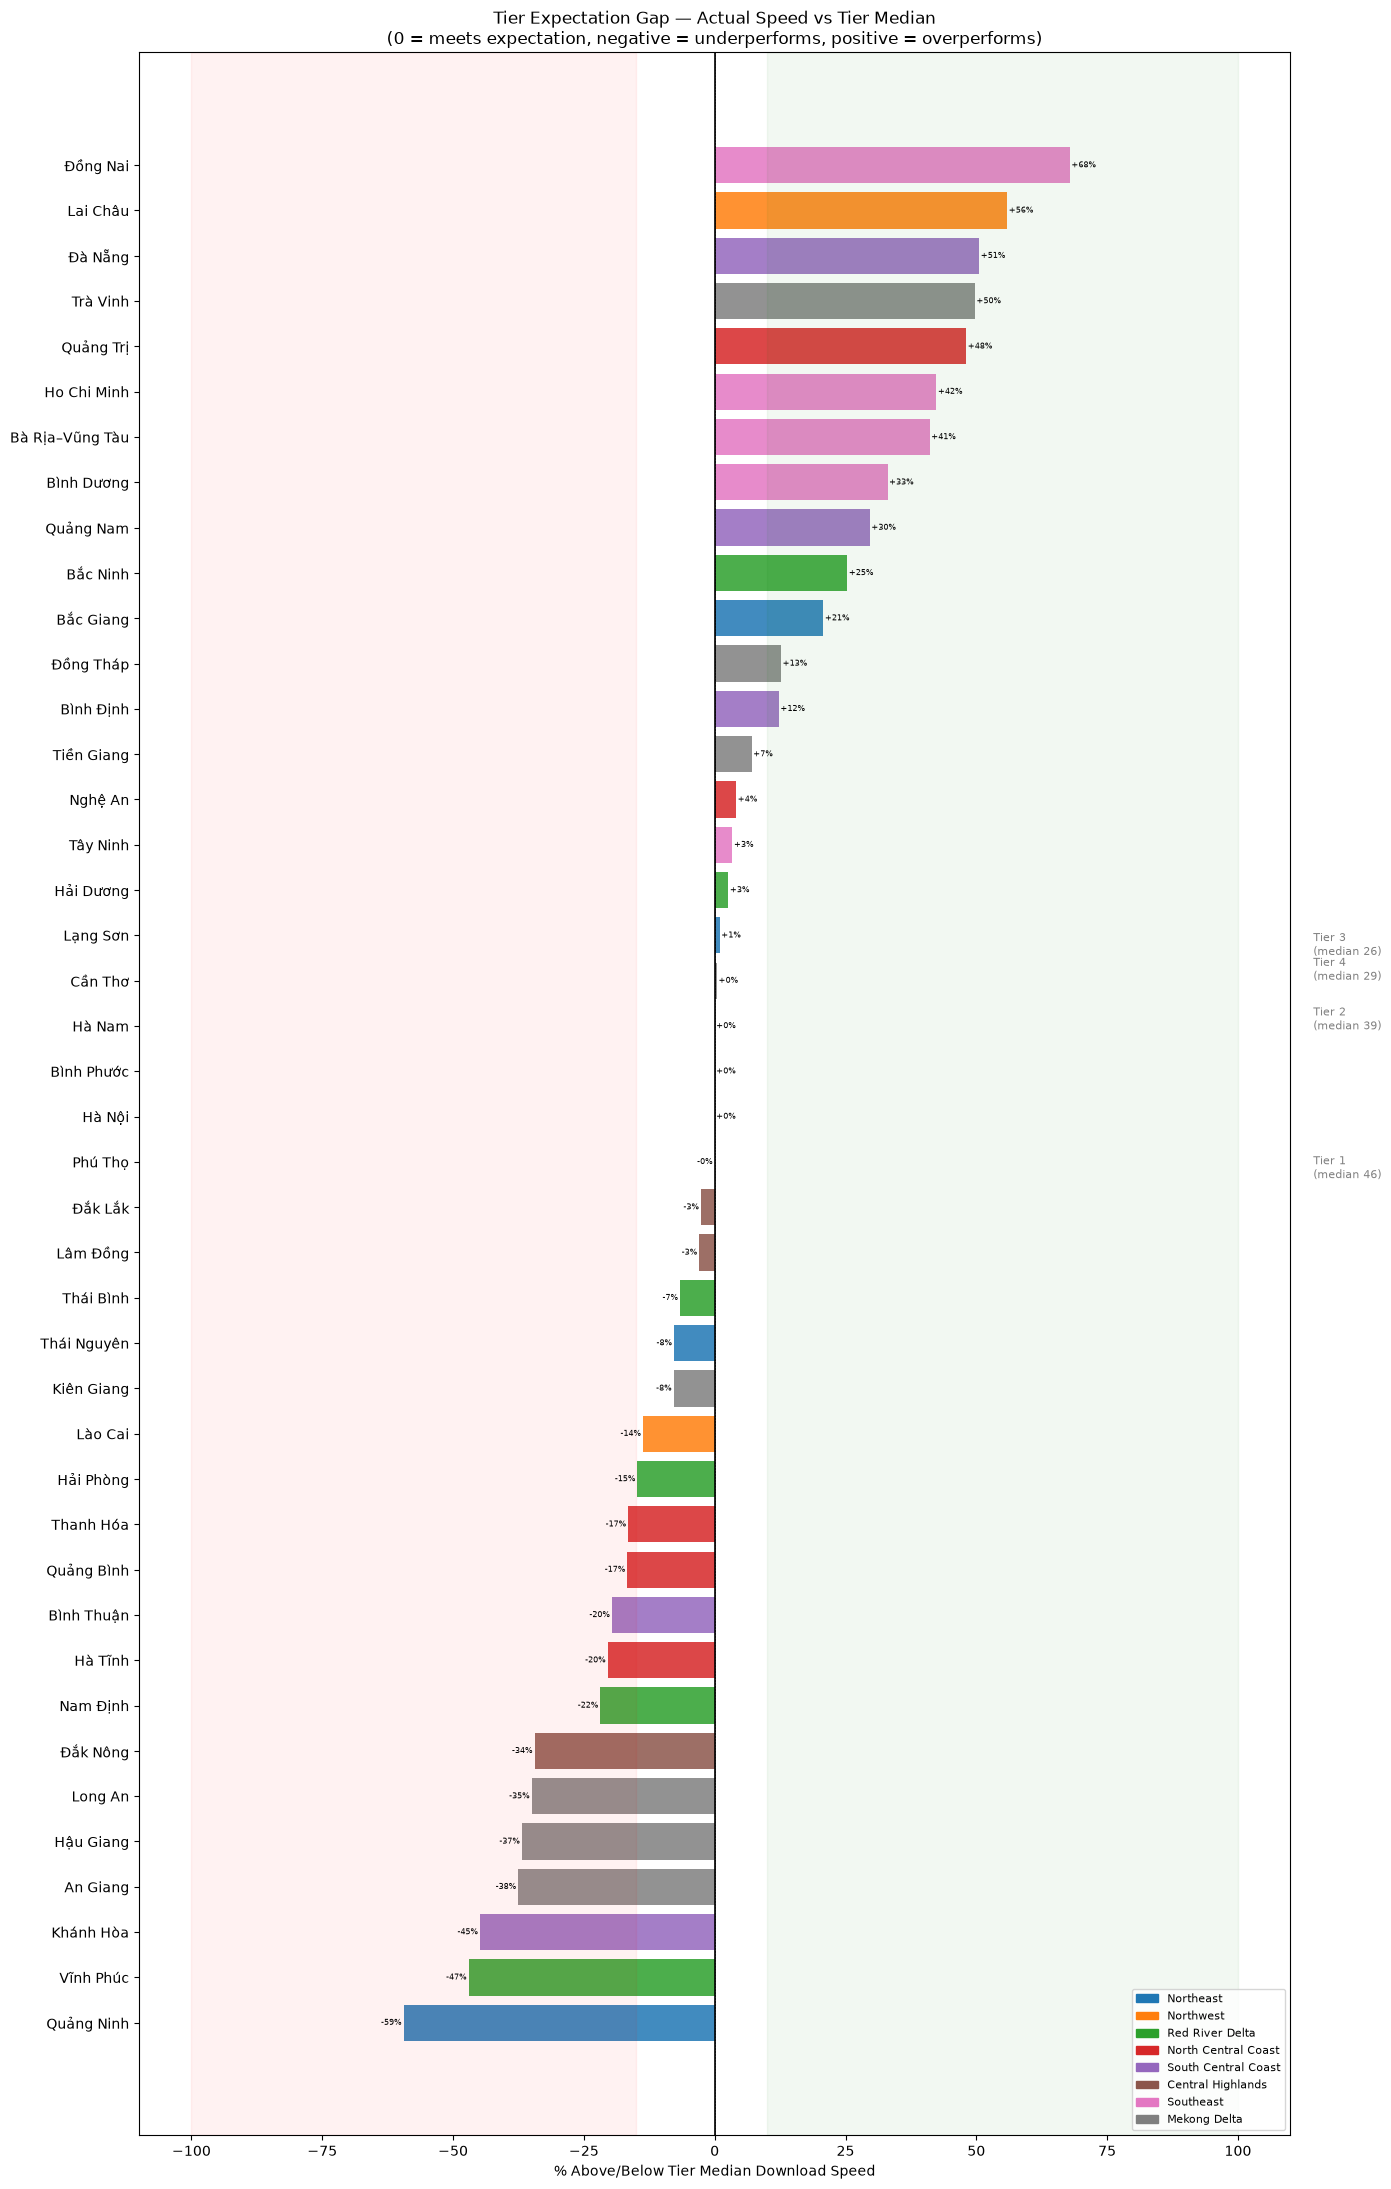

Biggest underperformers vs tier expectation:
      name  internet_tier   mean_dl  tier_expected  tier_residual
Quảng Ninh              1 18.569440      45.792330      -0.594486
 Vĩnh Phúc              1 24.261021      45.792330      -0.470195
 Khánh Hòa              1 25.256414      45.792330      -0.448458
  An Giang              1 28.599784      45.792330      -0.375446
 Hậu Giang              2 24.629501      38.993129      -0.368363
   Long An              1 29.778372      45.792330      -0.349708
  Đắk Nông              2 25.569985      38.993129      -0.344244
  Nam Định              4 22.293673      28.528045      -0.218535

Biggest overperformers vs tier expectation:
           name  internet_tier   mean_dl  tier_expected  tier_residual
       Đồng Nai              2 65.462341      38.993129       0.678817
       Lai Châu              4 44.477679      28.528045       0.559086
        Đà Nẵng              1 68.944808      45.792330       0.505597
       Trà Vinh              3 3

In [26]:
# Show each province's % deviation from its tier median
tier_gap = divergent_df[['name','region','internet_tier','mean_dl','tier_expected','tier_residual']].copy()
tier_gap = tier_gap.sort_values('tier_residual')

fig, ax = plt.subplots(figsize=(14, 22))

region_colors = {
    'Northeast': '#1f77b4',
    'Northwest': '#ff7f0e',
    'Red River Delta': '#2ca02c',
    'North Central Coast': '#d62728',
    'South Central Coast': '#9467bd',
    'Central Highlands': '#8c564b',
    'Southeast': '#e377c2',
    'Mekong Delta': '#7f7f7f',
}

colors = [region_colors.get(r, 'gray') for r in tier_gap['region']]
bars = ax.barh(tier_gap['name'], tier_gap['tier_residual'] * 100, color=colors, alpha=0.85)

# Tier median reference lines
ax.axvline(0, color='black', lw=1.2, label='Tier median (expected)')

# Annotate bars
for bar, val in zip(bars, tier_gap['tier_residual']):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val*100:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=6)

# Tier grouping lines
tier_boundaries = tier_gap.groupby('internet_tier').apply(lambda g: (g.index.min(), g.index.max()))
for t in sorted(tier_gap['internet_tier'].unique()):
    grp = tier_gap[tier_gap['internet_tier'] == t]
    median = tier_med[t]
    ax.axvline(0, color='black', lw=0.4, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.set_xlabel('% Above/Below Tier Median Download Speed')
ax.set_title('Tier Expectation Gap — Actual Speed vs Tier Median\n'
             '(0 = meets expectation, negative = underperforms, positive = overperforms)', fontsize=12)
ax.axvspan(-100, -15, alpha=0.05, color='red', label='Strong underperform')
ax.axvspan(10, 100, alpha=0.05, color='green')

# Annotate Tier brackets on y-axis
for t in sorted(tier_gap['internet_tier'].unique()):
    grp_idx = tier_gap[tier_gap['internet_tier']==t].index
    grp_pos = [list(tier_gap.index).index(i) for i in grp_idx]
    if grp_pos:
        mid = (min(grp_pos) + max(grp_pos)) / 2
        ax.annotate(f'Tier {t}\n(median {tier_med[t]:.0f})', xy=(1.02, mid/len(tier_gap)),
                    xycoords='axes fraction', va='center', fontsize=8, color='gray')

plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/22_tier_expectation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Biggest underperformers vs tier expectation:")
print(tier_gap.nsmallest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))
print()
print("Biggest overperformers vs tier expectation:")
print(tier_gap.nlargest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))


### 19. GDP per Capita vs Download Speed — Who Breaks the Rule?

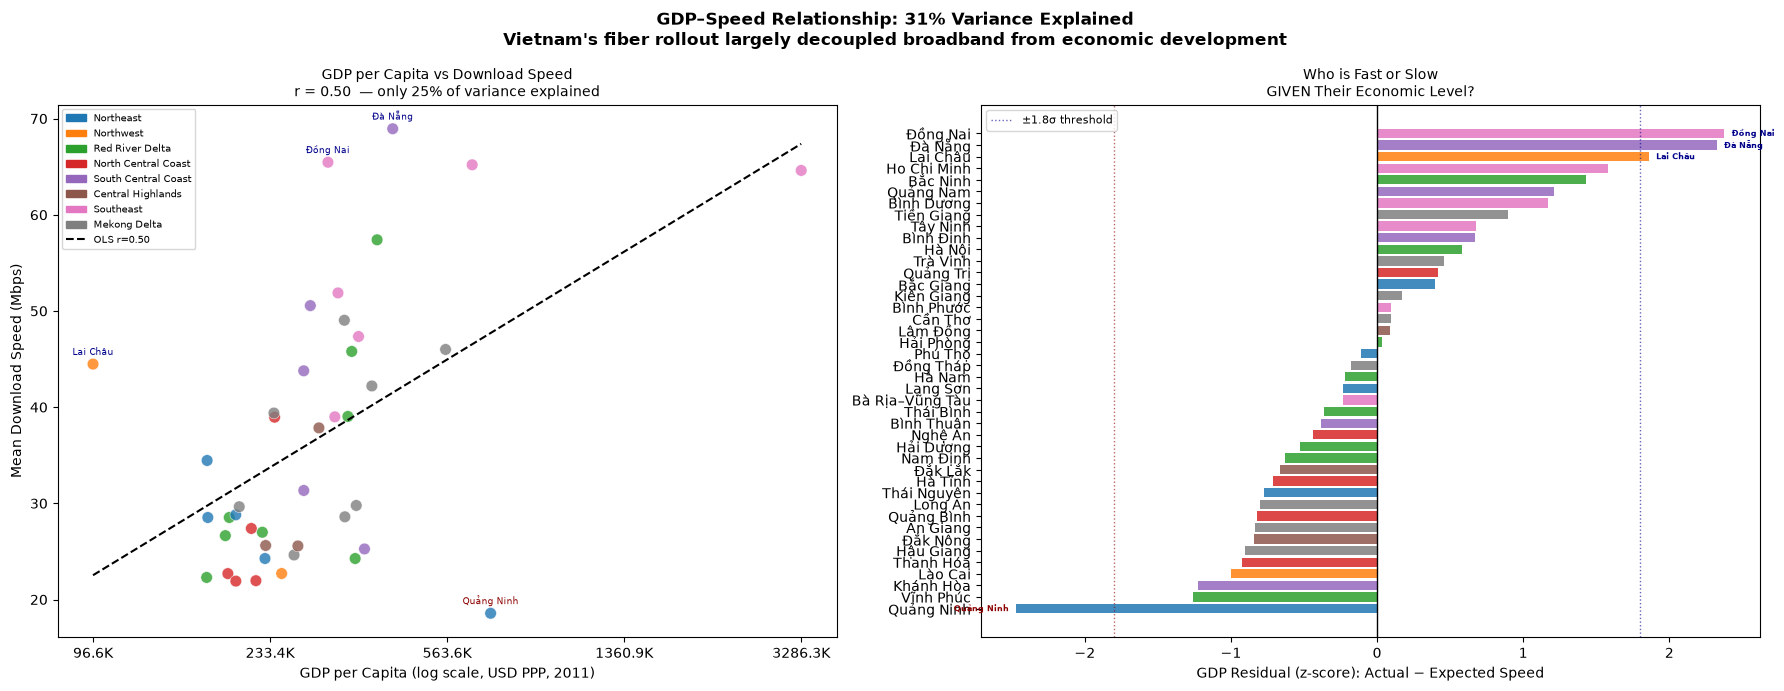

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: GDP scatter ──────────────────────────────────────────────────────────
ax = axes[0]
gdp_vals = divergent_df['gdp_per_capita_thb_2021']
colors_scatter = [region_colors.get(r, 'gray') for r in divergent_df['region']]

sc = ax.scatter(np.log(gdp_vals), divergent_df['mean_dl'],
                c=colors_scatter, s=70, alpha=0.8, edgecolors='white', lw=0.4)

# OLS line
x_fit = np.linspace(np.log(gdp_vals.min()), np.log(gdp_vals.max()), 200)
ax.plot(x_fit, int_g + slope_g * x_fit, 'k--', lw=1.5,
        label=f'OLS fit  r={r_g:.2f}')

# Label big residuals
threshold = 1.8
for _, row in divergent_df.iterrows():
    if abs(row['gdp_residual_z']) > threshold:
        ax.annotate(row['name'],
                    (np.log(row['gdp_per_capita_thb_2021']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['gdp_residual_z'] < 0 else 'darkblue')

ax.set_xlabel('GDP per Capita (log scale, USD PPP, 2011)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'GDP per Capita vs Download Speed\nr = {r_g:.2f}  — only {r_g**2*100:.0f}% of variance explained',
             fontsize=10)

# x-tick labels spaced across the actual data range (log scale)
_tick_vals = np.geomspace(gdp_vals.min(), gdp_vals.max(), 5)
ax.set_xticks(np.log(_tick_vals))
ax.set_xticklabels([f'{v/1000:.1f}K' if v >= 1000 else f'{v:.0f}' for v in _tick_vals])

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_g:.2f}')],
          fontsize=7)

# ── Right: residual bar chart ──────────────────────────────────────────────────
ax2 = axes[1]
resid_sorted = divergent_df.sort_values('gdp_residual_z')
cols2 = [region_colors.get(r, 'gray') for r in resid_sorted['region']]
bars2 = ax2.barh(resid_sorted['name'], resid_sorted['gdp_residual_z'], color=cols2, alpha=0.85)
ax2.axvline(0, color='black', lw=1)
ax2.axvline(1.8, color='darkblue', ls=':', lw=1, alpha=0.6, label='±1.8σ threshold')
ax2.axvline(-1.8, color='darkred', ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('GDP Residual (z-score): Actual − Expected Speed')
ax2.set_title('Who is Fast or Slow\nGIVEN Their Economic Level?', fontsize=10)
ax2.legend(fontsize=8)
# Add province labels for outliers
for bar, (_, row) in zip(bars2, resid_sorted.iterrows()):
    if abs(row['gdp_residual_z']) > 1.8:
        x = bar.get_width()
        ax2.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 row['name'], va='center', ha='left' if x >= 0 else 'right', fontsize=5.5,
                 color='darkblue' if x > 0 else 'darkred', fontweight='bold')

plt.suptitle('GDP–Speed Relationship: 31% Variance Explained\n'
             'Vietnam\'s fiber rollout largely decoupled broadband from economic development',
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/23_gdp_residual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 20. Population Density vs Speed — Greenfield Fiber Effect

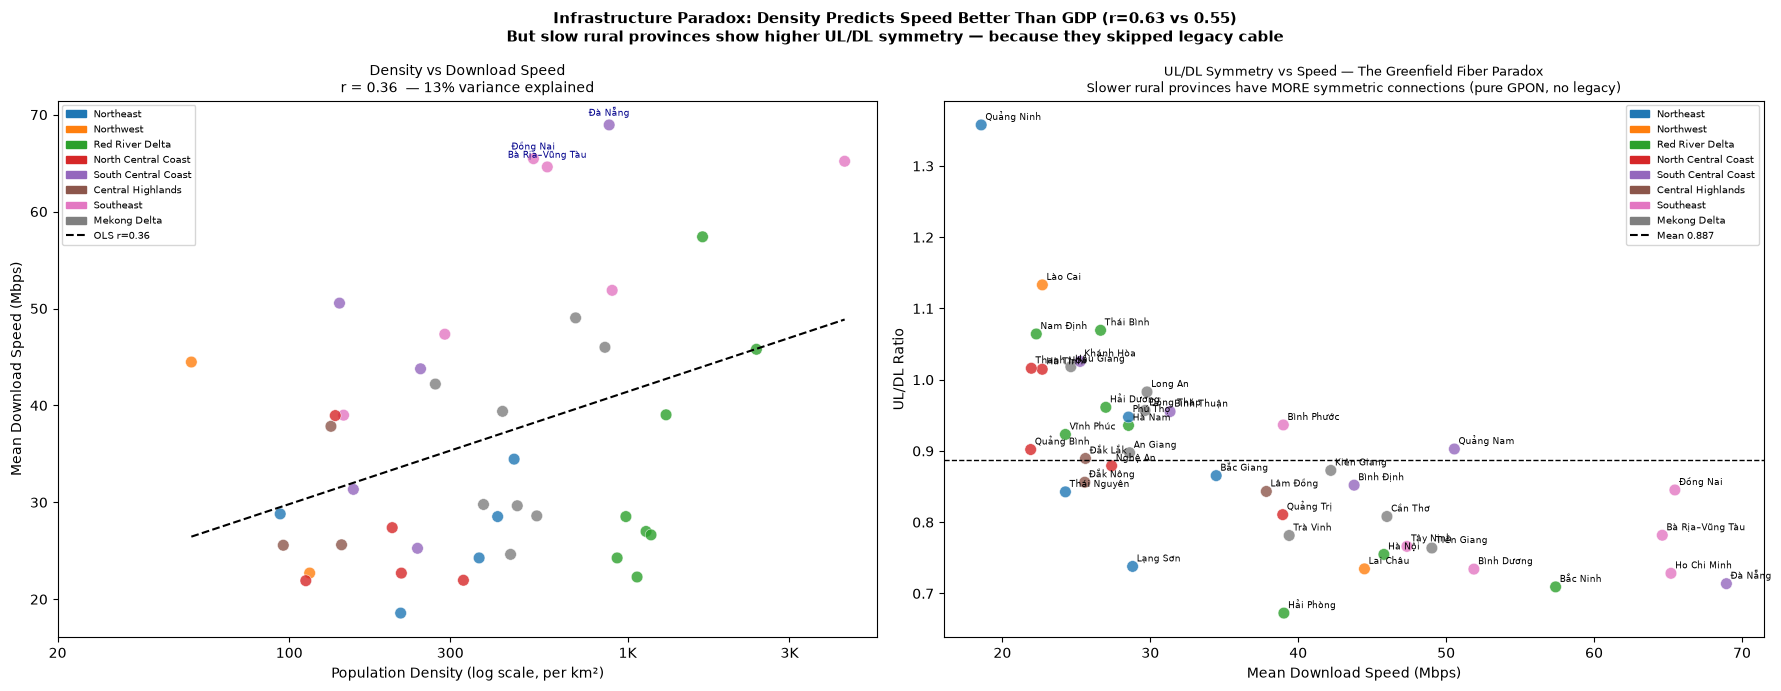

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Density scatter ──────────────────────────────────────────────────────
ax = axes[0]
den_vals = divergent_df['density_per_km2']
colors_s = [region_colors.get(r, 'gray') for r in divergent_df['region']]

ax.scatter(np.log1p(den_vals), divergent_df['mean_dl'],
           c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

x_fit2 = np.linspace(np.log1p(den_vals.min()), np.log1p(den_vals.max()), 200)
ax.plot(x_fit2, int_d + slope_d * x_fit2, 'k--', lw=1.5, label=f'OLS r={r_d:.2f}')

for _, row in divergent_df.iterrows():
    if abs(row['den_residual_z']) > 2.0:
        ax.annotate(row['name'],
                    (np.log1p(row['density_per_km2']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['den_residual_z'] < 0 else 'darkblue')

xticks_den = np.log1p([20, 100, 300, 1000, 3000])
ax.set_xticks(xticks_den)
ax.set_xticklabels(['20','100','300','1K','3K'])
ax.set_xlabel('Population Density (log scale, per km²)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'Density vs Download Speed\nr = {r_d:.2f}  — {r_d**2*100:.0f}% variance explained', fontsize=10)
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_d:.2f}')],
          fontsize=7)

# ── Right: UL/DL ratio vs DL speed — the "greenfield fiber paradox" ───────────
ax2 = axes[1]
ax2.scatter(divergent_df['mean_dl'], divergent_df['ul_dl_ratio'],
            c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

for _, row in divergent_df.iterrows():
    if row['ul_dl_ratio'] > 0.91 or row['ul_dl_ratio'] < 0.80 or row['mean_dl'] < 170:
        ax2.annotate(row['name'], (row['mean_dl'], row['ul_dl_ratio']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(3, 2), textcoords='offset points')

ax2.axhline(divergent_df['ul_dl_ratio'].mean(), color='black', ls='--', lw=1,
            label=f"Mean ratio {divergent_df['ul_dl_ratio'].mean():.3f}")
ax2.set_xlabel('Mean Download Speed (Mbps)')
ax2.set_ylabel('UL/DL Ratio')
ax2.set_title('UL/DL Symmetry vs Speed — The Greenfield Fiber Paradox\n'
              'Slower rural provinces have MORE symmetric connections (pure GPON, no legacy)', fontsize=9)
ax2.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["ul_dl_ratio"].mean():.3f}')], fontsize=7)

# Add trend arrow annotation
ax2.annotate('← slower but more symmetric\n   (rural greenfield fiber)',
             xy=(155, 0.905), fontsize=7.5, color='#6d6875',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))
ax2.annotate('faster but less symmetric →\n(urban legacy cable mix)',
             xy=(285, 0.800), fontsize=7.5, color='#e63946',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

plt.suptitle('Infrastructure Paradox: Density Predicts Speed Better Than GDP (r=0.63 vs 0.55)\n'
             'But slow rural provinces show higher UL/DL symmetry — because they skipped legacy cable',
             fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/24_uldl_greenfield.png', dpi=150, bbox_inches='tight')
plt.show()


### 21. NDT7 Coverage — Tests per 1,000 Population

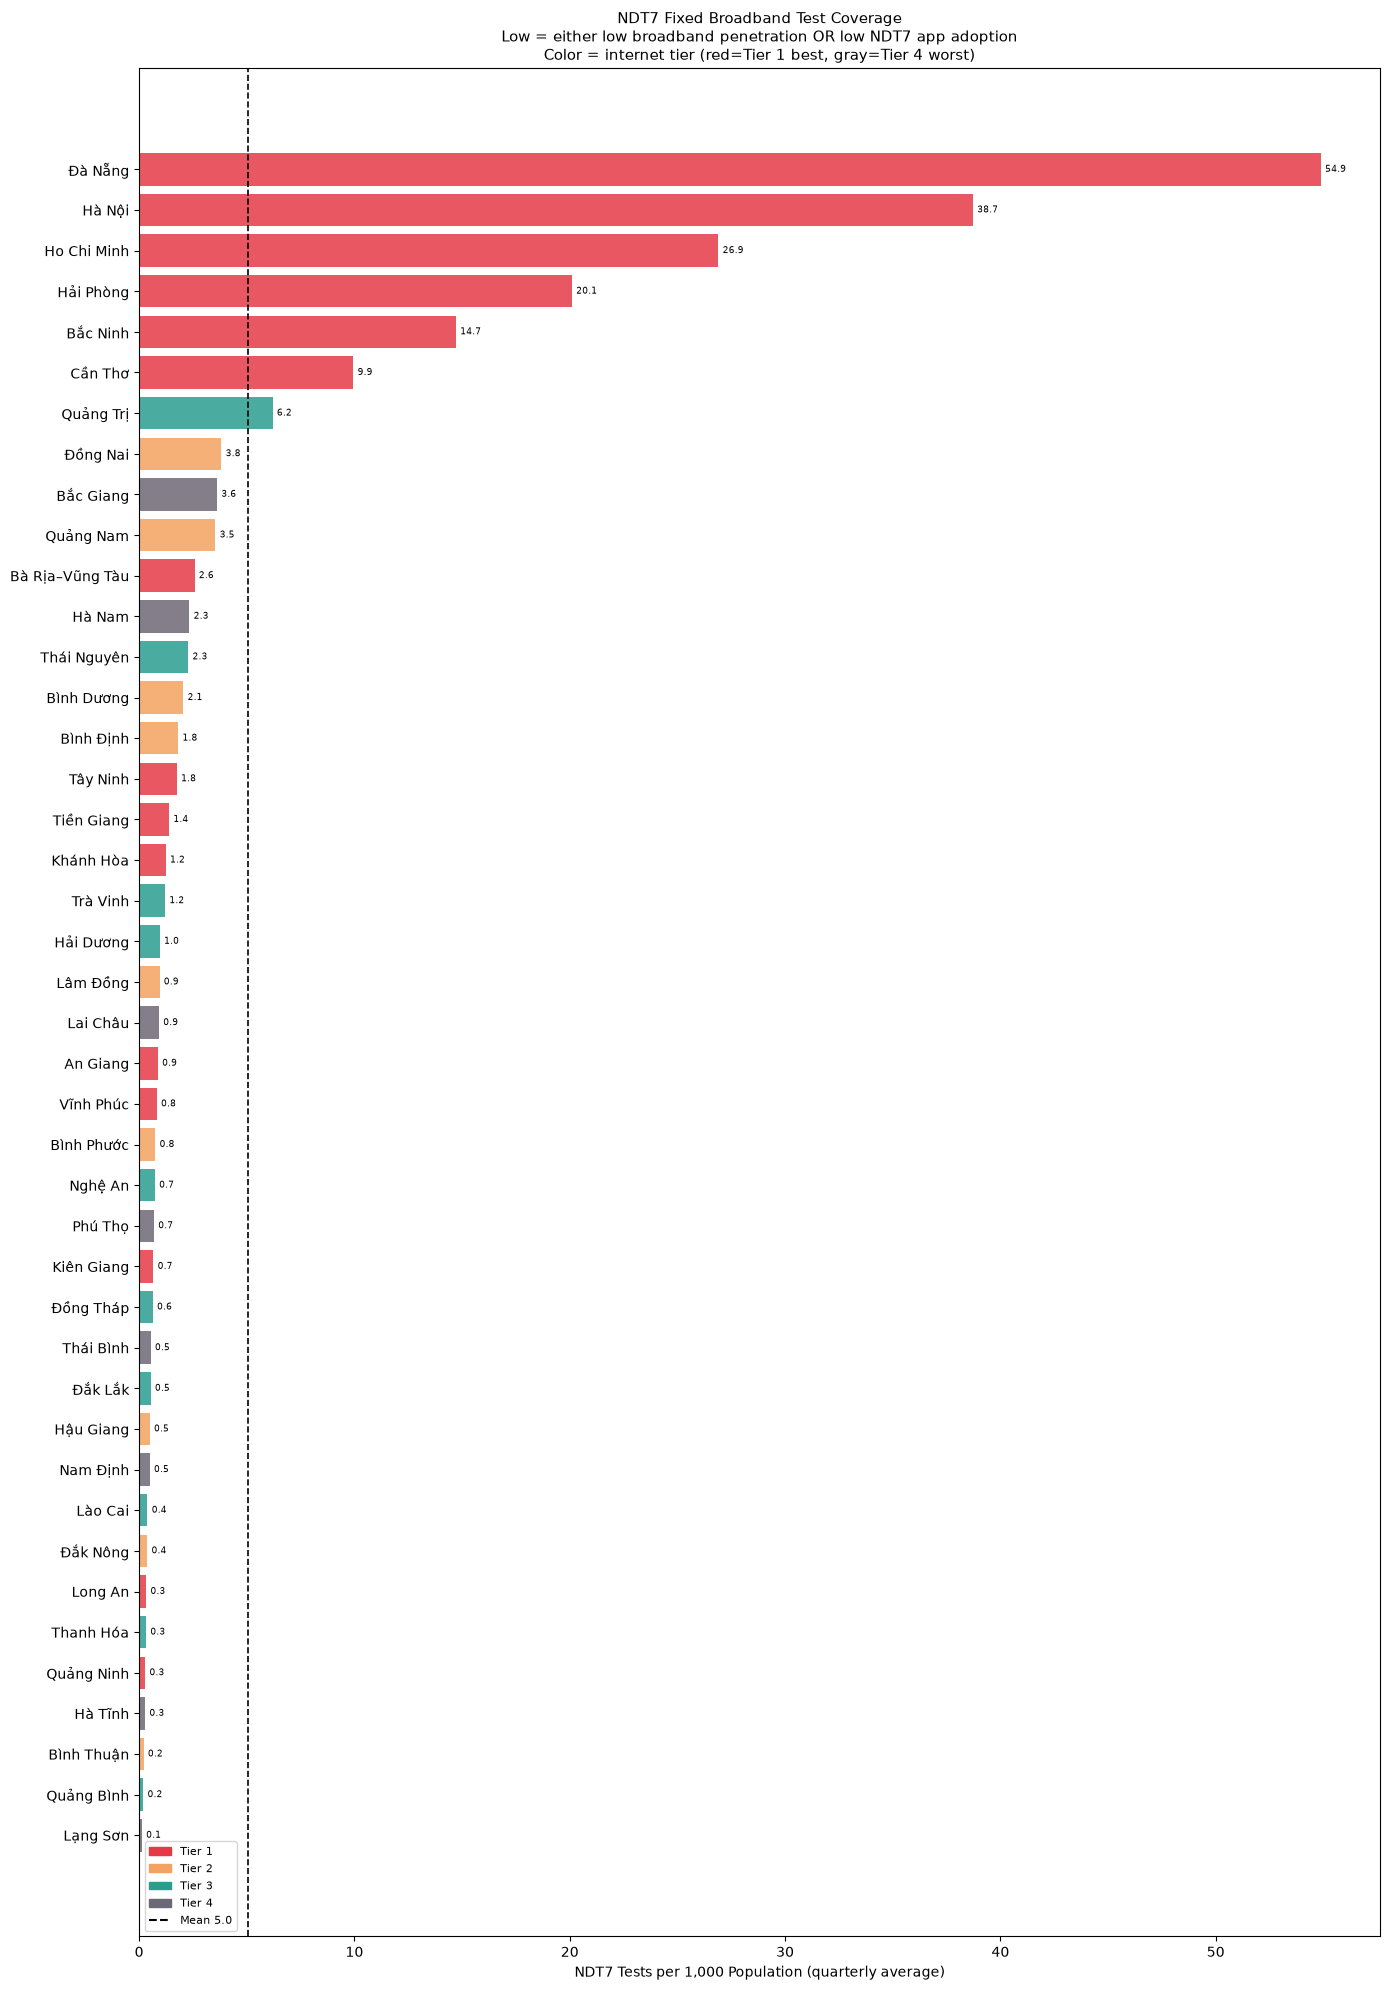

Top coverage (tests per 1000 pop):
       name              region  internet_tier  tests_per_1000_pop    mean_tests  pop_2024
    Đà Nẵng South Central Coast              1           54.885368  71021.666667   1294000
     Hà Nội     Red River Delta              1           38.723167 315438.916667   8146000
Ho Chi Minh           Southeast              1           26.904018 245499.166667   9125000
  Hải Phòng     Red River Delta              1           20.101809  42977.666667   2138000
   Bắc Ninh     Red River Delta              1           14.715273  21293.000000   1447000
    Cần Thơ        Mekong Delta              1            9.949710  14486.777778   1456000
  Quảng Trị North Central Coast              3            6.200509   4259.750000    687000
   Đồng Nai           Southeast              2            3.822849  12336.333333   3227000

Bottom coverage:
      name              region  internet_tier  tests_per_1000_pop  mean_tests  pop_2024
  Lạng Sơn           Northeast          

In [29]:
# Tests per 1000 pop = proxy for (broadband penetration × NDT7 app adoption × tech-savviness)
cov = divergent_df.sort_values('tests_per_1000_pop')
tier_palette = {1:'#e63946', 2:'#f4a261', 3:'#2a9d8f', 4:'#6d6875'}
colors_cov = [tier_palette.get(int(t), 'gray') for t in cov['internet_tier']]

fig, ax = plt.subplots(figsize=(14, 20))
bars = ax.barh(cov['name'], cov['tests_per_1000_pop'], color=colors_cov, alpha=0.85)
ax.axvline(divergent_df['tests_per_1000_pop'].mean(), color='black', ls='--', lw=1.2,
           label=f"National mean {divergent_df['tests_per_1000_pop'].mean():.1f}")

for bar, val in zip(bars, cov['tests_per_1000_pop']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=6.2)

patches_t = [mpatches.Patch(color=v, label=f'Tier {k}') for k, v in tier_palette.items()]
ax.legend(handles=patches_t + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["tests_per_1000_pop"].mean():.1f}')], fontsize=8)
ax.set_xlabel('NDT7 Tests per 1,000 Population (quarterly average)')
ax.set_title('NDT7 Fixed Broadband Test Coverage\n'
             'Low = either low broadband penetration OR low NDT7 app adoption\n'
             'Color = internet tier (red=Tier 1 best, gray=Tier 4 worst)', fontsize=11)
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/25_test_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top coverage (tests per 1000 pop):")
print(divergent_df.nlargest(8,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))
print()
print("Bottom coverage:")
print(divergent_df.nsmallest(10,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))


### 22. Composite Divergence Leaderboard — Top 20 Anomalous Provinces

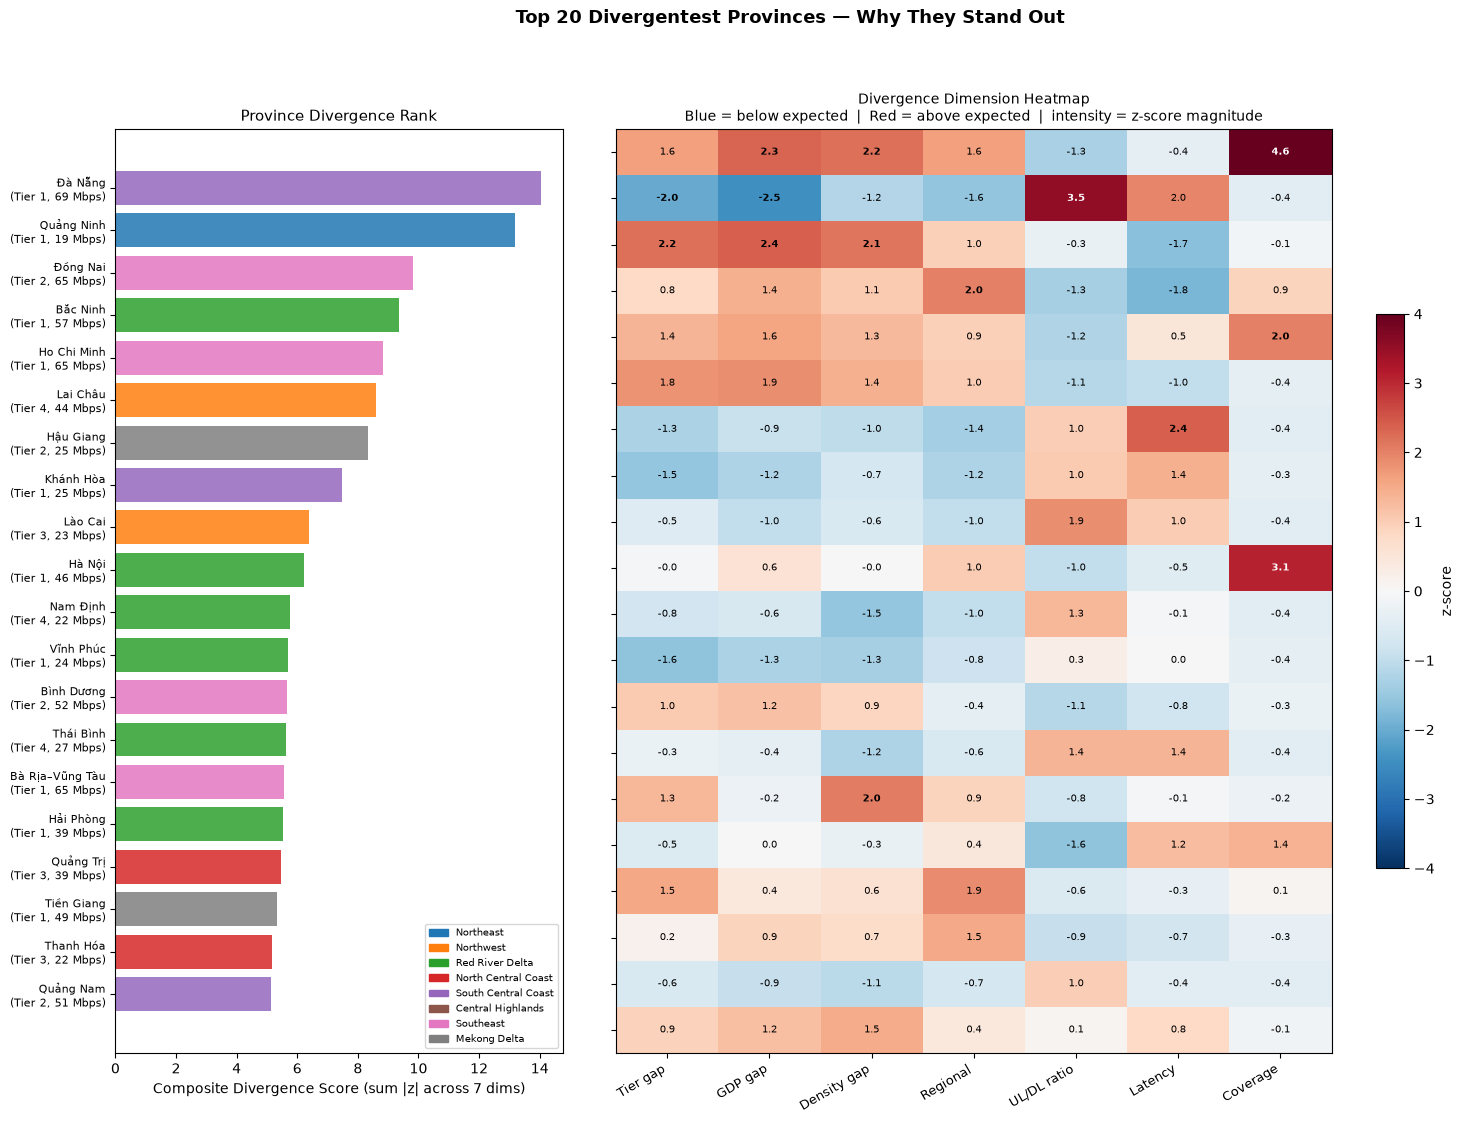


Full leaderboard table:
           name              region  internet_tier   mean_dl  divergence_score     GDP-z     Den-z     Reg-z   Ratio-z     Lat-z     Cov-z
        Đà Nẵng South Central Coast              1 68.944808         14.050223  2.324827  2.217238  1.627532 -1.301282 -0.386208  4.564632
     Quảng Ninh           Northeast              1 18.569440         13.191280 -2.468737 -1.186371 -1.580481  3.541127  1.958360 -0.435643
       Đồng Nai           Southeast              2 65.462341          9.804471  2.377301  2.147545  0.965606 -0.312036 -1.687386 -0.111507
       Bắc Ninh     Red River Delta              1 57.399146          9.350638  1.430425  1.055885  2.028263 -1.334928 -1.822985  0.885986
    Ho Chi Minh           Southeast              1 65.196897          8.844402  1.580889  1.286094  0.939667 -1.191752  0.486794  2.002191
       Lai Châu           Northwest              4 44.477679          8.606944  1.859935  1.419155  1.000000 -1.144784 -1.000000 -0.377138
  

In [30]:
TOP_N = min(20, len(divergent_df))
dims = ['tier_residual_z','gdp_residual_z','den_residual_z','regional_z',
        'ratio_z','lat_regional_z','coverage_z']
dim_labels = ['Tier gap','GDP gap','Density gap','Regional','UL/DL ratio','Latency','Coverage']

top20 = divergent_df.nlargest(TOP_N, 'divergence_score').copy().reset_index(drop=True)

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.08)

region_colors = {
    'Northeast': '#1f77b4',
    'Northwest': '#ff7f0e',
    'Red River Delta': '#2ca02c',
    'North Central Coast': '#d62728',
    'South Central Coast': '#9467bd',
    'Central Highlands': '#8c564b',
    'Southeast': '#e377c2',
    'Mekong Delta': '#7f7f7f',
}

# ── Left: Composite score bar ──────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0])
colors_bar = [region_colors.get(r, 'gray') for r in top20['region']]
y_pos = np.arange(TOP_N)
ax_bar.barh(y_pos, top20['divergence_score'], color=colors_bar, alpha=0.85)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(
    [f"{row['name']}\n(Tier {int(row['internet_tier'])}, {row['mean_dl']:.0f} Mbps)"
     for _, row in top20.iterrows()],
    fontsize=8
)
ax_bar.set_xlabel('Composite Divergence Score (sum |z| across 7 dims)')
ax_bar.set_title('Province Divergence Rank', fontsize=11)
ax_bar.invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax_bar.legend(handles=patches, fontsize=7, loc='lower right')

# ── Right: Heatmap of dimension z-scores ──────────────────────────────────────
ax_heat = fig.add_subplot(gs[1])
heat_data = top20[dims].values.astype(float)

im = ax_heat.imshow(heat_data, cmap='RdBu_r', aspect='auto', vmin=-4, vmax=4)
ax_heat.set_xticks(np.arange(len(dim_labels)))
ax_heat.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax_heat.set_yticks(np.arange(TOP_N))
ax_heat.set_yticklabels([''] * TOP_N)

for i in range(TOP_N):
    for j in range(len(dims)):
        val = heat_data[i, j]
        txt_color = 'white' if abs(val) > 2.5 else 'black'
        ax_heat.text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=7, color=txt_color,
                     fontweight='bold' if abs(val) > 2 else 'normal')

ax_heat.set_title(
    'Divergence Dimension Heatmap\n'
    'Blue = below expected  |  Red = above expected  |  intensity = z-score magnitude',
    fontsize=10
)
plt.colorbar(im, ax=ax_heat, label='z-score', shrink=0.6)

plt.suptitle('Top 20 Divergentest Provinces — Why They Stand Out', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/26_divergence_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull leaderboard table:")
print(top20[['name','region','internet_tier','mean_dl','divergence_score',
             'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']]
      .rename(columns={'gdp_residual_z':'GDP-z','den_residual_z':'Den-z','regional_z':'Reg-z',
                       'ratio_z':'Ratio-z','lat_regional_z':'Lat-z','coverage_z':'Cov-z'})
      .to_string(index=False))


### 23. Province Divergence Map

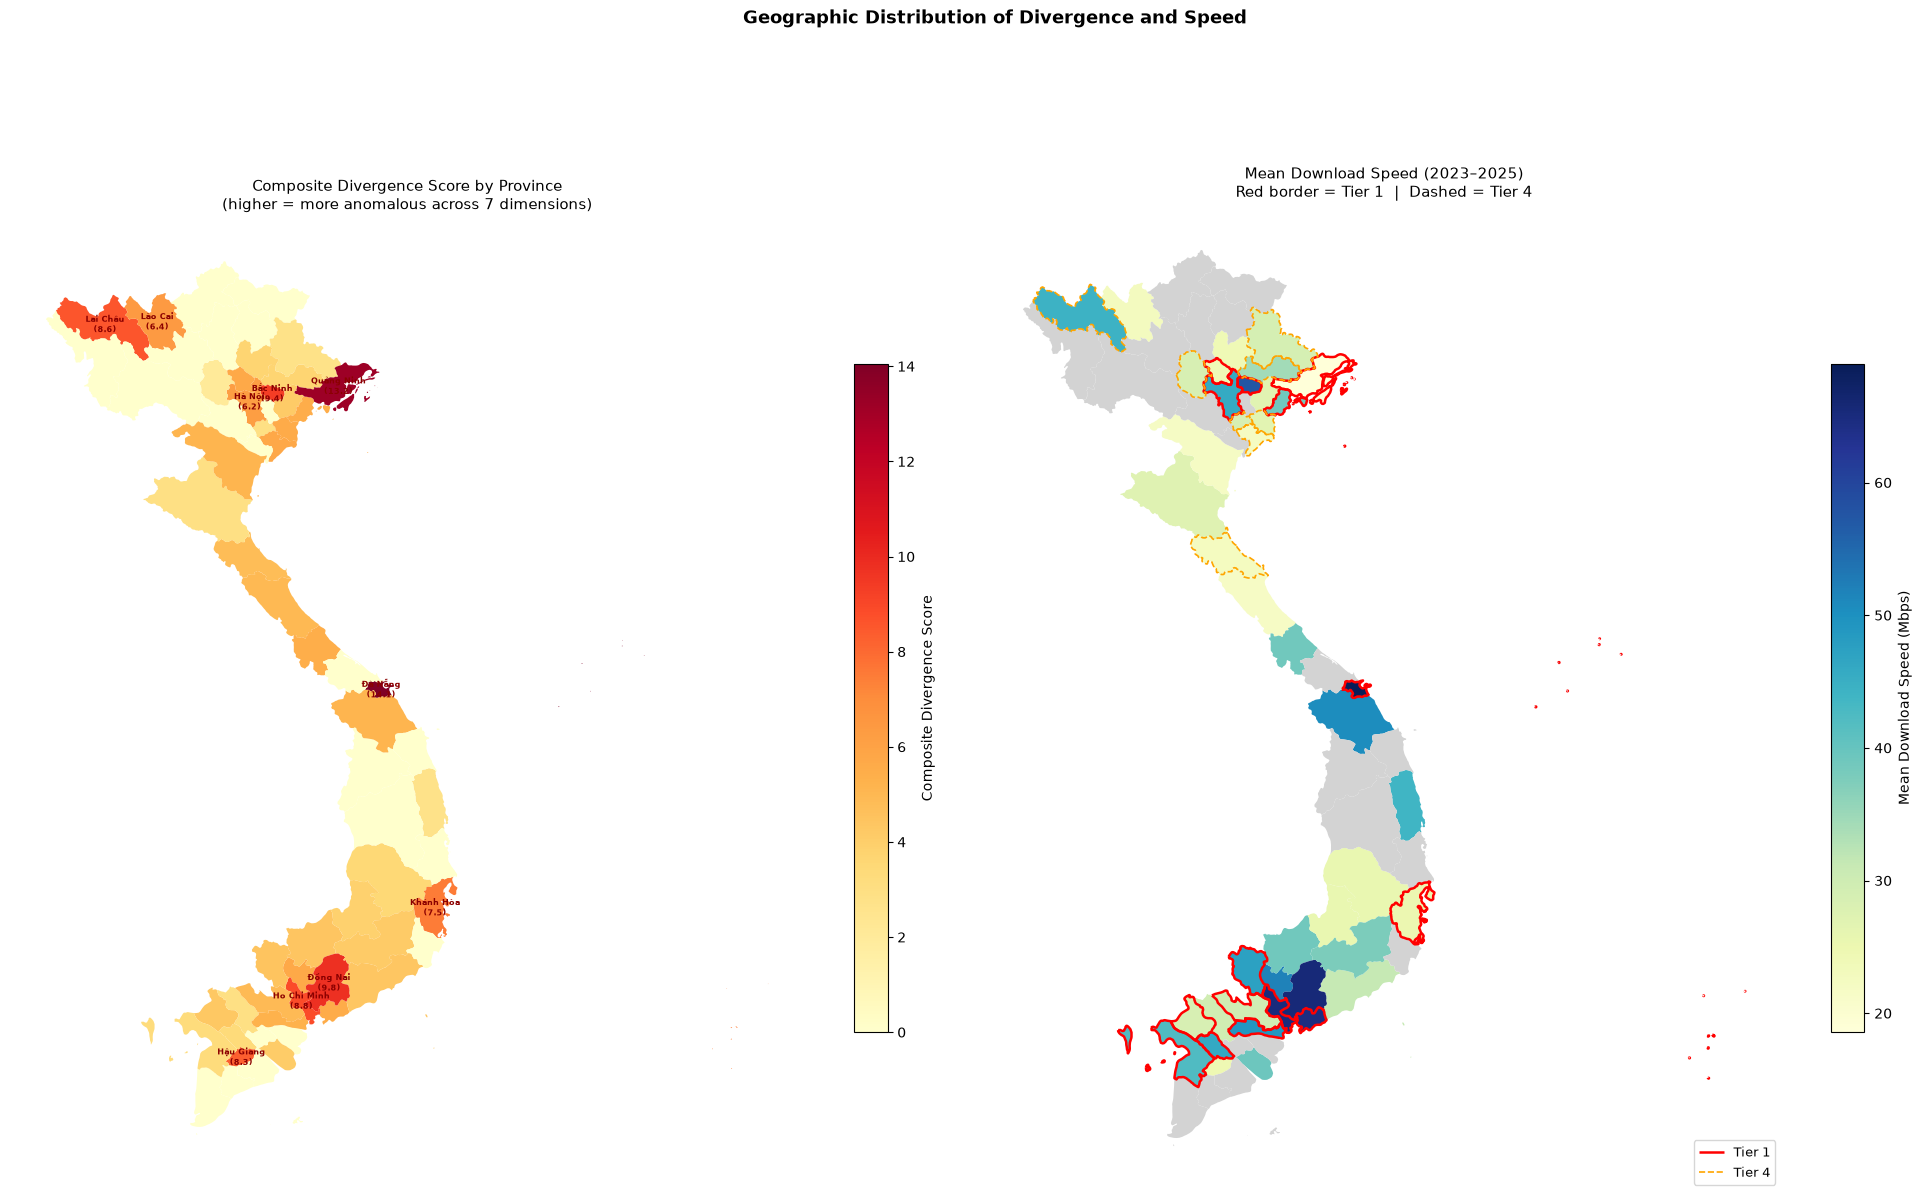

In [31]:
_GEOJSON = '../../data/geo/vietnam_provinces.geojson'

# Load GeoDataFrame with correct path (fallback if earlier cells used old path)
try:
    if 'thailand_gdf' not in dir() or thailand_gdf is None:
        raise NameError
    _ = thailand_gdf.shape  # verify it's valid
except (NameError, Exception):
    thailand_gdf = gpd.read_file(_GEOJSON).to_crs(4326)
    print("Loaded thailand_gdf from correct project path")

geo_divergent = thailand_gdf.copy()
geo_divergent = geo_divergent.merge(
    divergent_df[['name','divergence_score','mean_dl','internet_tier']],
    on='name', how='left'
)
geo_divergent['divergence_score'] = geo_divergent['divergence_score'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# ── Left: divergence score choropleth ──────────────────────────────────────────
ax1 = axes[0]
geo_divergent.plot('divergence_score', ax=ax1, cmap='YlOrRd',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Composite Divergence Score','shrink':0.5})

top10_names = divergent_df.nlargest(10, 'divergence_score')['name'].values
for _, row in geo_divergent.iterrows():
    if row['name'] in top10_names:
        c = row.geometry.centroid
        score = row['divergence_score']
        ax1.annotate(f"{row['name']}\n({score:.1f})",
                     (c.x, c.y), ha='center', va='center',
                     fontsize=5.5, color='darkred', fontweight='bold')

ax1.set_title('Composite Divergence Score by Province\n(higher = more anomalous across 7 dimensions)',
              fontsize=11)
ax1.set_axis_off()

# ── Right: download speed choropleth with tier overlay ────────────────────────
ax2 = axes[1]
geo_divergent.plot('mean_dl', ax=ax2, cmap='YlGnBu',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Mean Download Speed (Mbps)','shrink':0.5})

t1 = geo_divergent[geo_divergent['internet_tier'] == 1]
t1.boundary.plot(ax=ax2, color='red', linewidth=1.8, label='Tier 1')
t4 = geo_divergent[geo_divergent['internet_tier'] == 4]
t4.boundary.plot(ax=ax2, color='orange', linewidth=1.2, ls='--', label='Tier 4')

ax2.legend(fontsize=9, loc='lower right')
ax2.set_title('Mean Download Speed (2023–2025)\nRed border = Tier 1  |  Dashed = Tier 4',
              fontsize=11)
ax2.set_axis_off()

plt.suptitle('Geographic Distribution of Divergence and Speed', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ndt7/vietnam/27_divergence_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 24. Why Are They Divergent? — Annotated Province Notes

### 25. Full Province Divergence Table — All Provinces


In [32]:
# ── Merge display name ────────────────────────────────────────────────────────────
full_table = divergent_df.copy()
full_table = full_table.merge(
    prov_ref[['province_en','province_th']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

# ── Generate verdict ───────────────────────────────────────────────────────────
_DIM_ORDER = ['regional_z','gdp_residual_z','den_residual_z','tier_residual_z',
              'ratio_z','lat_regional_z','coverage_z']

def _note(d, v, region, tier):
    if d == 'gdp_residual_z':
        return f"fast for GDP (+{v:.1f}σ)" if v > 0 else f"slow for GDP ({v:.1f}σ)"
    if d == 'den_residual_z':
        return f"fast for density (+{v:.1f}σ)" if v > 0 else f"slow for density ({v:.1f}σ)"
    if d == 'tier_residual_z':
        return f"overperforms Tier {tier} (+{v:.1f}σ)" if v > 0 else f"underperforms Tier {tier} ({v:.1f}σ)"
    if d == 'regional_z':
        return f"fast vs {region} (+{v:.1f}σ)" if v > 0 else f"slow vs {region} ({v:.1f}σ)"
    if d == 'ratio_z':
        return f"symmetric UL/DL (+{v:.1f}σ)" if v > 0 else f"asymmetric UL/DL ({v:.1f}σ)"
    if d == 'lat_regional_z':
        return f"high latency (+{v:.1f}σ)" if v > 0 else f"ultra-low latency ({v:.1f}σ)"
    if d == 'coverage_z':
        return f"over-tested (+{v:.1f}σ)" if v > 0 else f"under-tested ({v:.1f}σ)"
    return f"{d}:{v:.1f}σ"

def make_verdict(r):
    region = r['region']
    tier   = int(r['internet_tier'])
    signals = [(abs(r[d]), d, r[d]) for d in _DIM_ORDER if abs(r[d]) >= 1.0]
    signals.sort(reverse=True)
    if not signals:
        return "unremarkable"
    return " | ".join(_note(d, v, region, tier) for _, d, v in signals[:3])

full_table['verdict'] = full_table.apply(make_verdict, axis=1)

# ── Table 0: Overall ranking (top 20) ─────────────────────────────────────────
from IPython.display import display, HTML

display(HTML("<h3>Overall Divergence Ranking — Top 20</h3>"))
t0 = (full_table.nlargest(20, 'divergence_score')
      [['name','province_th','region','internet_tier','mean_dl','divergence_score','verdict']]
      .rename(columns={'name':'Province','province_th':'Local Name','region':'Region',
                       'internet_tier':'Tier','mean_dl':'DL Mbps','divergence_score':'Score','verdict':'Why Divergent?'})
      .reset_index(drop=True))
t0.index += 1
tier_palette = {1:'#ffcccc', 2:'#ffe4b5', 3:'#d4f0d4', 4:'#dce0f5'}
styled0 = (t0.style
    .background_gradient(subset=['Score'], cmap='YlOrRd', vmin=0, vmax=20)
    .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
    .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
    .set_properties(**{'font-size':'11px','text-align':'left'})
    .set_properties(subset=['Why Divergent?'], **{'min-width':'320px','font-size':'10px'})
    .set_table_styles([
        {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
        {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
    ]))
display(styled0)

# ── Tables 1-7: Per-dimension top 8 over / bottom 8 under ─────────────────────
dim_meta = {
    'regional_z':      ('Regional Speed', 'fast vs region peers', 'slow vs region peers'),
    'gdp_residual_z':  ('GDP Gap', 'fast for GDP level', 'slow for GDP level'),
    'den_residual_z':  ('Density Gap', 'fast for density', 'slow for density'),
    'tier_residual_z': ('Tier Gap', 'overperforms tier', 'underperforms tier'),
    'ratio_z':         ('UL/DL Ratio', 'symmetric (fiber)', 'asymmetric (legacy)'),
    'lat_regional_z':  ('Latency (regional)', 'high latency', 'ultra-low latency'),
    'coverage_z':      ('Test Coverage', 'over-tested', 'under-tested'),
}

base_cols = ['name','province_th','region','internet_tier','mean_dl']

for dim, (title, over_label, under_label) in dim_meta.items():
    display(HTML(f"<h3>Dimension: {title} <small style='color:#888'>({dim})</small></h3>"))
    
    sub = full_table[base_cols + [dim, 'divergence_score']].copy()
    sub = sub.rename(columns={
        'name':'Province','province_th':'Local Name','region':'Region',
        'internet_tier':'Tier','mean_dl':'DL Mbps',
        dim:'z-score','divergence_score':'Total Score'
    })
    
    over  = sub.nlargest(8, 'z-score').copy()
    under = sub.nsmallest(8, 'z-score').copy()
    over['signal']  = over_label
    under['signal'] = under_label
    
    combined = pd.concat([over, under], ignore_index=True)
    combined = combined[['Province','Local Name','Region','Tier','DL Mbps','z-score','signal','Total Score']]
    combined['z-score'] = combined['z-score'].round(2)
    combined['DL Mbps'] = combined['DL Mbps'].round(1)
    combined['Total Score'] = combined['Total Score'].round(2)
    
    styled_dim = (combined.style
        .background_gradient(subset=['z-score'], cmap='RdBu_r', vmin=-4, vmax=4)
        .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
        .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
        .set_properties(**{'font-size':'11px','text-align':'left'})
        .set_table_styles([
            {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
            {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
        ])
        .hide(axis='index'))
    display(styled_dim)
    display(HTML("<hr style='margin:16px 0'>"))

print(f"Provinces: {len(full_table)}")
print(f"Score range: {full_table['divergence_score'].min():.2f} – {full_table['divergence_score'].max():.2f}")
print(f"|z|>2 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 2).any(axis=1).sum()}")
print(f"|z|>3 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 3).any(axis=1).sum()}")
print(f"Unremarkable: {(full_table[[*_DIM_ORDER]].abs() < 1.0).all(axis=1).sum()}")

# Save styled table as HTML
_html_path = '../../outputs/ndt7/vietnam/28_divergence_table.html'
with open(_html_path, 'w') as _f:
    _f.write(styled0.to_html())
print(f"Saved: {_html_path}")


,Province,Local Name,Region,Tier,DL Mbps,Score,Why Divergent?
1,Đà Nẵng,Đà Nẵng,South Central Coast,1,68.944808,14.050223,over-tested (+4.6σ) | fast for GDP (+2.3σ) | fast for density (+2.2σ)
2,Quảng Ninh,Quảng Ninh,Northeast,1,18.569440,13.191280,symmetric UL/DL (+3.5σ) | slow for GDP (-2.5σ) | underperforms Tier 1 (-2.0σ)
3,Đồng Nai,Đồng Nai,Southeast,2,65.462341,9.804471,fast for GDP (+2.4σ) | overperforms Tier 2 (+2.2σ) | fast for density (+2.1σ)
4,Bắc Ninh,Bắc Ninh,Red River Delta,1,57.399146,9.350638,fast vs Red River Delta (+2.0σ) | ultra-low latency (-1.8σ) | fast for GDP (+1.4σ)
5,Ho Chi Minh,Ho Chi Minh,Southeast,1,65.196897,8.844402,over-tested (+2.0σ) | fast for GDP (+1.6σ) | overperforms Tier 1 (+1.4σ)
6,Lai Châu,Lai Châu,Northwest,4,44.477679,8.606944,fast for GDP (+1.9σ) | overperforms Tier 4 (+1.8σ) | fast for density (+1.4σ)
7,Hậu Giang,Hậu Giang,Mekong Delta,2,24.629501,8.321159,high latency (+2.4σ) | slow vs Mekong Delta (-1.4σ) | underperforms Tier 2 (-1.3σ)
8,Khánh Hòa,Khánh Hòa,South Central Coast,1,25.256414,7.486719,underperforms Tier 1 (-1.5σ) | high latency (+1.4σ) | slow for GDP (-1.2σ)
9,Lào Cai,Lào Cai,Northwest,3,22.703069,6.393882,symmetric UL/DL (+1.9σ) | slow vs Northwest (-1.0σ) | high latency (+1.0σ)
10,Hà Nội,Hà Nội,Red River Delta,1,45.792330,6.213251,over-tested (+3.1σ) | fast vs Red River Delta (+1.0σ)


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Bắc Ninh,Bắc Ninh,Red River Delta,1,57.400000,2.030000,fast vs region peers,9.350000
Quảng Trị,Quảng Trị,North Central Coast,3,39.000000,1.900000,fast vs region peers,5.450000
Đà Nẵng,Đà Nẵng,South Central Coast,1,68.900000,1.630000,fast vs region peers,14.050000
Tiền Giang,Tiền Giang,Mekong Delta,1,49.000000,1.510000,fast vs region peers,5.320000
Bắc Giang,Bắc Giang,Northeast,4,34.500000,1.420000,fast vs region peers,3.680000
Lâm Đồng,Lâm Đồng,Central Highlands,2,37.800000,1.410000,fast vs region peers,4.150000
Cần Thơ,Cần Thơ,Mekong Delta,1,46.000000,1.150000,fast vs region peers,3.390000
Hà Nội,Hà Nội,Red River Delta,1,45.800000,1.030000,fast vs region peers,6.210000
Bình Phước,Bình Phước,Southeast,2,39.000000,-1.620000,slow vs region peers,4.410000
Quảng Ninh,Quảng Ninh,Northeast,1,18.600000,-1.580000,slow vs region peers,13.190000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Đồng Nai,Đồng Nai,Southeast,2,65.500000,2.380000,fast for GDP level,9.800000
Đà Nẵng,Đà Nẵng,South Central Coast,1,68.900000,2.320000,fast for GDP level,14.050000
Lai Châu,Lai Châu,Northwest,4,44.500000,1.860000,fast for GDP level,8.610000
Ho Chi Minh,Ho Chi Minh,Southeast,1,65.200000,1.580000,fast for GDP level,8.840000
Bắc Ninh,Bắc Ninh,Red River Delta,1,57.400000,1.430000,fast for GDP level,9.350000
Quảng Nam,Quảng Nam,South Central Coast,2,50.600000,1.210000,fast for GDP level,5.140000
Bình Dương,Bình Dương,Southeast,2,51.900000,1.170000,fast for GDP level,5.670000
Tiền Giang,Tiền Giang,Mekong Delta,1,49.000000,0.900000,fast for GDP level,5.320000
Quảng Ninh,Quảng Ninh,Northeast,1,18.600000,-2.470000,slow for GDP level,13.190000
Vĩnh Phúc,Vĩnh Phúc,Red River Delta,1,24.300000,-1.260000,slow for GDP level,5.690000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Đà Nẵng,Đà Nẵng,South Central Coast,1,68.900000,2.220000,fast for density,14.050000
Đồng Nai,Đồng Nai,Southeast,2,65.500000,2.150000,fast for density,9.800000
Bà Rịa–Vũng Tàu,Bà Rịa–Vũng Tàu,Southeast,1,64.600000,2.040000,fast for density,5.550000
Quảng Nam,Quảng Nam,South Central Coast,2,50.600000,1.500000,fast for density,5.140000
Lai Châu,Lai Châu,Northwest,4,44.500000,1.420000,fast for density,8.610000
Ho Chi Minh,Ho Chi Minh,Southeast,1,65.200000,1.290000,fast for density,8.840000
Bắc Ninh,Bắc Ninh,Red River Delta,1,57.400000,1.060000,fast for density,9.350000
Tây Ninh,Tây Ninh,Southeast,1,47.300000,0.960000,fast for density,4.480000
Nam Định,Nam Định,Red River Delta,4,22.300000,-1.530000,slow for density,5.750000
Vĩnh Phúc,Vĩnh Phúc,Red River Delta,1,24.300000,-1.320000,slow for density,5.690000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Đồng Nai,Đồng Nai,Southeast,2,65.500000,2.200000,overperforms tier,9.800000
Lai Châu,Lai Châu,Northwest,4,44.500000,1.810000,overperforms tier,8.610000
Đà Nẵng,Đà Nẵng,South Central Coast,1,68.900000,1.630000,overperforms tier,14.050000
Trà Vinh,Trà Vinh,Mekong Delta,3,39.400000,1.600000,overperforms tier,4.120000
Quảng Trị,Quảng Trị,North Central Coast,3,39.000000,1.550000,overperforms tier,5.450000
Ho Chi Minh,Ho Chi Minh,Southeast,1,65.200000,1.360000,overperforms tier,8.840000
Bà Rịa–Vũng Tàu,Bà Rịa–Vũng Tàu,Southeast,1,64.600000,1.310000,overperforms tier,5.550000
Bình Dương,Bình Dương,Southeast,2,51.900000,1.050000,overperforms tier,5.670000
Quảng Ninh,Quảng Ninh,Northeast,1,18.600000,-2.020000,underperforms tier,13.190000
Vĩnh Phúc,Vĩnh Phúc,Red River Delta,1,24.300000,-1.610000,underperforms tier,5.690000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Quảng Ninh,Quảng Ninh,Northeast,1,18.600000,3.540000,symmetric (fiber),13.190000
Lào Cai,Lào Cai,Northwest,3,22.700000,1.850000,symmetric (fiber),6.390000
Thái Bình,Thái Bình,Red River Delta,4,26.600000,1.370000,symmetric (fiber),5.630000
Nam Định,Nam Định,Red River Delta,4,22.300000,1.330000,symmetric (fiber),5.750000
Khánh Hòa,Khánh Hòa,South Central Coast,1,25.300000,1.040000,symmetric (fiber),7.490000
Hậu Giang,Hậu Giang,Mekong Delta,2,24.600000,0.990000,symmetric (fiber),8.320000
Thanh Hóa,Thanh Hóa,North Central Coast,3,22.000000,0.970000,symmetric (fiber),5.150000
Hà Tĩnh,Hà Tĩnh,North Central Coast,4,22.700000,0.960000,symmetric (fiber),4.810000
Hải Phòng,Hải Phòng,Red River Delta,1,39.000000,-1.610000,asymmetric (legacy),5.540000
Bắc Ninh,Bắc Ninh,Red River Delta,1,57.400000,-1.330000,asymmetric (legacy),9.350000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Hậu Giang,Hậu Giang,Mekong Delta,2,24.600000,2.390000,high latency,8.320000
Quảng Ninh,Quảng Ninh,Northeast,1,18.600000,1.960000,high latency,13.190000
Quảng Bình,Quảng Bình,North Central Coast,3,21.900000,1.600000,high latency,4.960000
Khánh Hòa,Khánh Hòa,South Central Coast,1,25.300000,1.410000,high latency,7.490000
Thái Bình,Thái Bình,Red River Delta,4,26.600000,1.370000,high latency,5.630000
Bình Phước,Bình Phước,Southeast,2,39.000000,1.290000,high latency,4.410000
Hải Phòng,Hải Phòng,Red River Delta,1,39.000000,1.240000,high latency,5.540000
Đắk Lắk,Đắk Lắk,Central Highlands,3,25.600000,1.160000,high latency,3.560000
Bắc Ninh,Bắc Ninh,Red River Delta,1,57.400000,-1.820000,ultra-low latency,9.350000
Đồng Nai,Đồng Nai,Southeast,2,65.500000,-1.690000,ultra-low latency,9.800000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Đà Nẵng,Đà Nẵng,South Central Coast,1,68.900000,4.560000,over-tested,14.050000
Hà Nội,Hà Nội,Red River Delta,1,45.800000,3.080000,over-tested,6.210000
Ho Chi Minh,Ho Chi Minh,Southeast,1,65.200000,2.000000,over-tested,8.840000
Hải Phòng,Hải Phòng,Red River Delta,1,39.000000,1.380000,over-tested,5.540000
Bắc Ninh,Bắc Ninh,Red River Delta,1,57.400000,0.890000,over-tested,9.350000
Cần Thơ,Cần Thơ,Mekong Delta,1,46.000000,0.450000,over-tested,3.390000
Quảng Trị,Quảng Trị,North Central Coast,3,39.000000,0.110000,over-tested,5.450000
Đồng Nai,Đồng Nai,Southeast,2,65.500000,-0.110000,over-tested,9.800000
Lạng Sơn,Lạng Sơn,Northeast,4,28.800000,-0.450000,under-tested,2.790000
Quảng Bình,Quảng Bình,North Central Coast,3,21.900000,-0.440000,under-tested,4.960000


Provinces: 42
Score range: 2.08 – 14.05
|z|>2 in any dim: 8
|z|>3 in any dim: 3
Unremarkable: 6
Saved: ../../outputs/ndt7/vietnam/28_divergence_table.html


## Data Export

Already exported by `vietnam_ndt7_prep.ipynb` — this notebook only reads `data/exports/ndt7_vietnam_province_quarterly.csv`, it doesn't need to write it again. Confirming the file this notebook ran against, for provenance:

In [33]:
import os
PATH = '../../data/exports/ndt7_vietnam_province_quarterly.csv'
print(f"Source: {PATH}")
print(f"Rows in source file: {len(pd.read_csv(PATH))}")
print(f"Last modified: {pd.Timestamp(os.path.getmtime(PATH), unit='s')}")


Source: ../../data/exports/ndt7_vietnam_province_quarterly.csv
Rows in source file: 733
Last modified: 2026-07-13 03:58:44.530352591
